### In this notebook, we will define a series of function that helps us to fasten our analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    # "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    # "#843c39", # Dark red
    # "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_trainig=colors_sets[9]
color_validation='orange'
color_testing=colors_sets[3]

marker_trainig='s'
marker_validation='*'
marker_testing='o'



size_trainig=30
size_validation=80
size_testing=35

alpha_trainig=0.8
alpha_validation=0.9
alpha_testing=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
key_list = models_selected[1:]

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [2]:
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}

filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T
filtered_NZ

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

## Necessary functions

In [3]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)


In [388]:
def filtered_NZ_extraction(filtered_NZ): #This function will extract isotopes that we want in our analysis

    #We start applying constraints to the above NZ array
    filtered_NZ_new = [] # Create a new list
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >= 8)) & ( (isotope[0]%2 == 0) & (isotope[1]%2 == 0) ):
            filtered_NZ_new.append(isotope) # Choose the isotope that satisfies the above condition
    filtered_NZ = np.array(filtered_NZ_new) # Turn this into an array
    return filtered_NZ

def unified_NZ(models_data_sets, models_selected, filtered_NZ):
    for model in models_selected: # Loop throught every model
        filtered_NZ_new = [] 
        for isotope in filtered_NZ:
            if ((models_data_sets[model]["N"] == isotope[0]) & (models_data_sets[model]["Z"] == isotope[1])).any():
                filtered_NZ_new.append(isotope) #Choose every isotope that does appears in the model we are considering
        filtered_NZ = np.array(filtered_NZ_new)# Update our list of filtered_NZ and loop through the remaining models.
    #A dataframe containing this NZ inputs
    filtered_NZ_df = {'N' : filtered_NZ.T[0], 'Z': filtered_NZ.T[1]}
    filtered_NZ_df = pd.DataFrame(filtered_NZ_df)

    return filtered_NZ, filtered_NZ_df

def selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, heterogeneous_data_type, num_properties):
    selected_models_data_sets_list = []
    for i in range(num_properties):
        selected_models_data_sets=pd.DataFrame(filtered_NZ_df)

        for model in models_selected:
            a = pd.merge(filtered_NZ_df, pd.DataFrame(models_data_sets[model]), how = 'inner', on  = ['N', 'Z'])
            selected_models_data_sets[model] = a[heterogeneous_data_type[i]]
        selected_models_data_sets.rename(columns={models_selected[0]: 'truth'}, inplace=True)
        selected_models_data_sets_list.append(selected_models_data_sets)
    return selected_models_data_sets_list

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    models_output = selected_models_data_sets #This gives the initial values for models output
    
    # We will add a column of mass number and rearrange our dataframe
    models_output["A"] = models_output["N"] + models_output["Z"] 
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2]
    models_output = models_output[cols]

    #Next steps is to extract this dataframe at train,validation,test coordinates
    models_output_train = models_output.iloc[train_coordinates]
    models_output_validation = models_output.iloc[validation_coordinates]
    models_output_test = models_output.iloc[test_coordinates]

    return [models_output,models_output_train,models_output_validation,models_output_test]

def filtered_models_output(Selected_element, models_output_list): 
    Z_range=(Selected_element,Selected_element)
    N_range=(0,300)
    models_output, models_output_train, models_output_validation, models_output_test = models_output_list

    
    filtered_models_output = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1]) & 
                         (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1])]  
    
    filtered_models_output_train = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                         (models_output_train['N'] >= N_range[0]) & (models_output_train['N'] <= N_range[1])]
    
    filtered_models_output_test = models_output_test[(models_output_test['Z'] >= Z_range[0]) & (models_output_test['Z'] <= Z_range[1]) & 
                         (models_output_test['N'] >= N_range[0]) & (models_output_test['N'] <= N_range[1])]
    
    filtered_models_output_validation = models_output_validation[(models_output_validation['Z'] >= Z_range[0]) & (models_output_validation['Z'] <= Z_range[1]) & 
                         (models_output_validation['N'] >= N_range[0]) & (models_output_validation['N'] <= N_range[1])]
    
    
    stable_selected_isotope=[]
    
    for i in range(len(stable_coordinates)):
        if stable_coordinates[i][1]==Selected_element:
            stable_selected_isotope.append(stable_coordinates[i])
    
    stable_selected_isotope=np.array(stable_selected_isotope)
    
    # df[df['Column1'].isin(values_array)]
    
    filtered_models_output_stable = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                         (models_output_train['N'].isin(stable_selected_isotope.T[0]))]
    
    return [filtered_models_output,filtered_models_output_train, filtered_models_output_validation, filtered_models_output_test, filtered_models_output_stable]

def models_PC_output(Vt_hat, model_predictions, predictions_mean):
    models_PC = {}

    models_PC["PC_0"] = predictions_mean
    
    for i in range(components_kept):
        models_PC["PC_" + str(i+1)] = np.dot(Vt_hat[i], model_predictions.T)
    
    # models_PC["N"] = models_output["N"]
    # models_PC["Z"] = models_output["Z"]
    # models_PC["A"] = models_PC["N"] + models_PC["Z"]
    
    models_PC = pd.DataFrame(models_PC)

    return models_PC

def rndm_m_mass_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_mass = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_mass= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_mass.append(yvals_rand_mass +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_mass)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_mass),1.0 * samples[i][-2]**2 ) )))  
        
    lower_mass = np.percentile(rndm_m_mass, 2.5, axis = 0)
    median_mass = np.percentile(rndm_m_mass, 50, axis = 0)
    upper_mass = np.percentile(rndm_m_mass, 97.5, axis = 0)

    return [lower_mass, median_mass, upper_mass]

def rndm_m_radius_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_radius = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_radius= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * samples[i][-1]**2 ) )))  
        
    lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
    median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
    upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

    return [lower_radius, median_radius, upper_radius]

def rndm_m_mass_calculator_coverage(samples, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * samples_rand[i][-2]**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m

def rndm_m_radius_calculator_coverage(samples, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * samples_rand[i][-1]**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m
    

def coverage_calculation(rndm_m_full, models_output):
    percentiles = np.arange(0, 101, 5)


    data_total=len(rndm_m_full.T)
    data_true=models_output["truth"].tolist()
    M_evals=len(rndm_m_full)
    
    
    coverage = []
    
    for p in percentiles:
        count_covered = 0
        for i in range(data_total):
            # Sort model evaluations for the i-th data point
            sorted_evals = np.sort(rndm_m_full.T[i])
            
            # Find indices for lower and upper bounds of the credible interval
            lower_idx = int((0.5 - p / 200) * M_evals)
            upper_idx = int((0.5 + p / 200) * M_evals) - 1  # Adjusted to avoid out-of-bounds
            
            # Check if the true value y[i] is within this interval
            if sorted_evals[lower_idx] <= data_true[i] <= sorted_evals[upper_idx]:
                count_covered += 1
                
        # Calculate and store the coverage percentage
        coverage.append(count_covered / data_total * 100)
        
    return coverage
    

In [283]:
def plot_filtered_supermodel(supermodel_predictions_range, filtered_models_output_list, Z, unit, property, Constraint, save_fig):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], -median/filtered_models_output['A'], color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    plt.plot(filtered_models_output["N"], -lower/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    plt.plot(filtered_models_output["N"], -upper/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    
    plt.fill_between(filtered_models_output["N"], -lower/filtered_models_output['A'], -upper/filtered_models_output['A'], color="darkkhaki",alpha=0.3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = -filtered_models_output_train['truth']/filtered_models_output_train["A"], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_trainig,color=color_trainig,s=100,marker=marker_trainig,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = -filtered_models_output_validation['truth']/filtered_models_output_validation["A"], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = -filtered_models_output_test['truth']/filtered_models_output_test["A"], label = "$\mathcal{X}_0^{te}$", alpha = alpha_testing,color=color_testing,s=100,marker=marker_testing,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y =- filtered_models_output_stable['truth']/filtered_models_output_stable["A"], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}/A$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    plt.savefig(f'{save_fig}')
    plt.show()

In [5]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full)

In [6]:
filtered_NZ= filtered_NZ_extraction(filtered_NZ) #Extract even even nuclei with N, Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ(models_data_sets, models_selected, filtered_NZ) #Choose nuclei that appears in every models of interest

In [200]:
Full_set = np.copy(filtered_NZ)

In [7]:
# Extracting 2 data frames that contains predictions of different properties of nuclei
selected_models_data_sets_mass, selected_models_data_sets_radius = selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, \
                                                                                                        heterogeneous_data_type, num_properties)

In [8]:
#Traditional way with stable coordinates to seperate our data points

distance1=2
distance2=3

training_set, validation_set, test_set,train_coordinates, validation_coordinates,test_coordinates=separate_points_distance_allSets(filtered_NZ, stable_coordinates, distance1,distance2)

In [9]:
#Extract models output of different categories (mass and radius) and classify them into 4 regions: all,train, validation, test
models_output_mass_list = models_output_extraction(selected_models_data_sets_mass, train_coordinates, validation_coordinates, test_coordinates)
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates, validation_coordinates, test_coordinates)

In [10]:
#Separate them for further use
[models_output_mass, models_output_mass_train, models_output_mass_validation, models_output_mass_test] = models_output_mass_list
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

In [11]:
filtered_models_output_mass_list = filtered_models_output(50, models_output_mass_list)
filtered_models_output_radius_list = filtered_models_output(50, models_output_radius_list)

In [12]:
filtered_models_output_mass = filtered_models_output_mass_list[0]
filtered_models_output_mass_train = filtered_models_output_mass_list[1]
filtered_models_output_mass_validation = filtered_models_output_mass_list[2]
filtered_models_output_mass_test = filtered_models_output_mass_list[3]
filtered_models_output_mass_stable = filtered_models_output_mass_list[4]

filtered_models_output_radius = filtered_models_output_radius_list[0]
filtered_models_output_radius_train = filtered_models_output_radius_list[1]
filtered_models_output_radius_validation = filtered_models_output_radius_list[2]
filtered_models_output_radius_test = filtered_models_output_radius_list[3]
filtered_models_output_radius_stable = filtered_models_output_radius_list[4]

model_predictions_mass=models_output_mass[key_list].values
model_predictions_mass_train=models_output_mass_train[key_list].values
model_predictions_mass_validation=models_output_mass_validation[key_list].values
model_predictions_mass_test=models_output_mass_test[key_list].values

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values

model_predictions_combined = np.vstack((model_predictions_mass, model_predictions_radius))
model_predictions_combined_train = np.vstack((model_predictions_mass_train, model_predictions_radius_train))
model_predictions_combined_validation = np.vstack((model_predictions_mass_validation, model_predictions_radius_validation))
model_predictions_combined_test = np.vstack((model_predictions_mass_test, model_predictions_radius_test))

predictions_mean_mass= np.mean(model_predictions_mass, axis=1)
predictions_mean_mass_train= np.mean(model_predictions_mass_train, axis=1)
predictions_mean_mass_validation= np.mean(model_predictions_mass_validation, axis=1)
predictions_mean_mass_test= np.mean(model_predictions_mass_test, axis=1)

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_combined= np.mean(model_predictions_combined, axis=1)
predictions_mean_combined_train= np.mean(model_predictions_combined_train, axis=1)
predictions_mean_combined_validation= np.mean(model_predictions_combined_validation, axis=1)
predictions_mean_combined_test= np.mean(model_predictions_combined_test, axis=1)

In [13]:
centering_data = True

if centering_data:
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,None]
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train.reshape(300,1)
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,np.newaxis]

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(300,1)
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]

if centering_data:
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, None]
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train.reshape(600,1)
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, np.newaxis]

# PCA

In [14]:
# In this notebook we will perfrom our analysis on the combined forecasts of radius and mass. First is to combined the forecast together

In [355]:
model_predictions_combined_train_processed

array([[ 1.47288344e+00, -9.81165556e-02,  5.60883444e-01, ...,
        -1.84880556e-01, -8.44621556e-01, -5.84765656e+00],
       [-1.43840444e-01, -7.12840444e-01, -4.20840444e-01, ...,
        -1.72294444e-01, -9.54984444e-02, -6.01265944e+00],
       [-1.28766944e+00, -8.65669444e-01, -6.48669444e-01, ...,
        -3.34336444e-01,  4.04025556e-02, -6.46042744e+00],
       ...,
       [ 5.34277778e-03,  1.43427778e-02,  2.53427778e-02, ...,
        -1.75612222e-02, -1.25882222e-02,  2.98477778e-03],
       [-4.38611111e-03,  6.61388889e-03,  9.61388889e-03, ...,
        -1.35041111e-02, -1.03681111e-02,  3.78588889e-03],
       [-1.78244444e-03,  8.21755556e-03,  1.52175556e-02, ...,
        -1.48394444e-02, -1.05864444e-02,  4.03155556e-03]])

[9.95658402e+01 3.91832674e+01 2.98178463e+01 2.51907298e+01
 1.80578179e+01 1.72332595e+01 9.60140022e+00 4.89362067e+00
 5.11555767e-12]


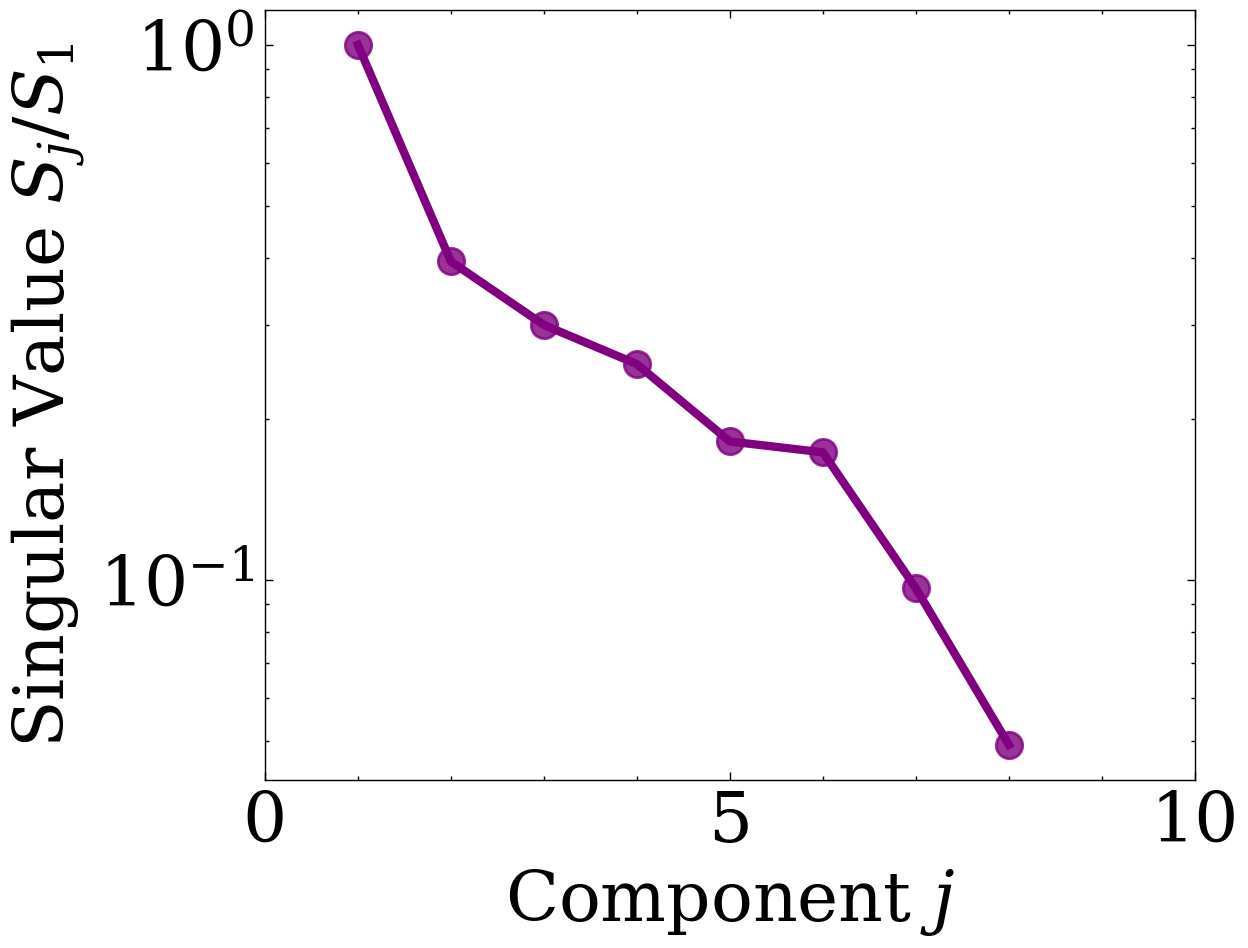

In [15]:
U, S, Vt = np.linalg.svd(model_predictions_combined_train_processed)

print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,5,10])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.show()

In [351]:
components_kept = 5
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])

# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

In [352]:
models_PC_combined = models_PC_output(Vt_hat, model_predictions_combined, predictions_mean_combined)
models_PC_combined_train = models_PC_output(Vt_hat, model_predictions_combined_train, predictions_mean_combined_train)
models_PC_combined_validation = models_PC_output(Vt_hat, model_predictions_combined_validation, predictions_mean_combined_validation)
models_PC_combined_test = models_PC_output(Vt_hat, model_predictions_combined_test, predictions_mean_combined_test)

In [368]:
np.dot(Vt_hat[0], model_predictions_combined_train.T)[0]

0.03505512942431677

In [372]:
predictions_mean_combined_train_matrix = np.tile(predictions_mean_combined_train, (9,1)).T
np.dot(Vt_hat[0], predictions_mean_combined_train_matrix.T)

array([2.66453526e-15, 3.44169138e-15, 3.44169138e-15, 3.05311332e-15,
       3.60822483e-15, 3.77475828e-15, 4.44089210e-15, 3.77475828e-15,
       4.55191440e-15, 4.88498131e-15, 5.10702591e-15, 4.77395901e-15,
       4.99600361e-15, 5.55111512e-15, 5.55111512e-15, 6.55031585e-15,
       5.44009282e-15, 6.32827124e-15, 6.32827124e-15, 6.77236045e-15,
       7.10542736e-15, 5.88418203e-15, 7.43849426e-15, 7.10542736e-15,
       7.77156117e-15, 7.99360578e-15, 8.21565038e-15, 8.21565038e-15,
       6.88338275e-15, 7.77156117e-15, 8.43769499e-15, 8.65973959e-15,
       9.32587341e-15, 9.10382880e-15, 9.76996262e-15, 7.77156117e-15,
       8.43769499e-15, 8.88178420e-15, 9.54791801e-15, 9.76996262e-15,
       1.11022302e-14, 9.32587341e-15, 1.04360964e-14, 1.08801856e-14,
       1.06581410e-14, 1.17683641e-14, 9.76996262e-15, 9.76996262e-15,
       1.13242749e-14, 1.13242749e-14, 1.22124533e-14, 1.19904087e-14,
       1.13242749e-14, 1.17683641e-14, 1.13242749e-14, 1.19904087e-14,
      

### There is one thing that we do not yet understand is that the compitation of Vt_hat with model_predictions yields the same result as the computation Vt_hat with model_predictions_procssed

In [373]:
np.sum(Vt[0])

2.220446049250313e-15

In [353]:
models_PC_combined

,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5
0,127.553117,0.035055,0.030695,-0.099078,-0.109689,0.079785
1,142.135840,0.054498,-0.011041,-0.075940,-0.089776,0.077380
2,154.080669,0.068914,-0.042332,-0.095889,-0.063381,0.090550
3,164.223844,0.084158,-0.069884,-0.123452,-0.038654,0.106783
4,171.440113,0.088835,-0.084706,-0.156477,-0.016382,0.133577
...,...,...,...,...,...,...
1253,6.085766,-0.000096,0.000043,-0.000058,-0.000355,0.000325
1254,6.096302,-0.000134,0.000087,-0.000153,-0.000431,0.000329
1255,6.115493,-0.000096,0.000090,-0.000023,-0.000519,0.000075
1256,6.125436,-0.000124,0.000104,-0.000100,-0.000532,0.000135


In [229]:
X = np.copy(U_hat)

y_mass = models_output_mass_train['truth'] - predictions_mean_mass_train
y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train
y = np.hstack((y_mass,y_radius))

X_train = models_PC_combined_train.values
X_validation = models_PC_combined_validation.values
X_test = models_PC_combined_test.values
X_full = models_PC_combined.values

## Since we are exploring the new approach, let's consider both unconstrained and complex case

### Unconstrained

In [230]:
nu0_chosen = 10
sigma20_chosen = 0.5

In [231]:
def gibbs_sampler(y, X, iterations,prior_info):
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
    b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), 
    #nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    b_mean_cov_inv=np.linalg.inv(b_mean_cov)

    y_mass = y[:300]
    y_radius = y[300:]
    X_mass = X[:300,:]
    X_radius = X[300:,:]
    
    X_T_X_mass=X_mass.T.dot(X_mass)
    X_T_X_mass_inv = np.linalg.inv(X_T_X_mass)

    X_T_X_radius=X_radius.T.dot(X_radius)
    X_T_X_radius_inv = np.linalg.inv(X_T_X_radius)
    
    n = len(y_mass)
    
    X_T_X=X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)

    b_data = X_T_X_inv.dot(X.T).dot(y)

    
    
    supermodel=X.dot(b_data)
    

    residuals = y - supermodel 

    
    
    sigma2_mass = np.sum(residuals**2) / len(residuals) 
    sigma2_radius = np.sum(residuals**2) / len(residuals) 
    # cov_matrix = sigma2 * X_T_X_inv

    samples_beta = []
    samples_sigma2_mass = []
    samples_sigma2_radius = []
    
    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data

        
        cov_matrix = np.linalg.inv(X_T_X_mass/sigma2_mass + X_T_X_radius/sigma2_radius
                                   + b_mean_cov_inv)
        
        mean_vector = cov_matrix.dot(   b_mean_cov_inv.dot(b_mean_prior)+ X_mass.T.dot(y_mass)/sigma2_mass + X_radius.T.dot(y_radius)/sigma2_radius  )
        
        
        b_current = np.random.multivariate_normal(mean_vector, cov_matrix)

        
        
        
        # Sample from the conditional posterior of sigma2 given bs and data
        supermodel_mass=X_mass.dot(b_current)
        
        residuals_mass = y_mass - supermodel_mass

        supermodel_radius=X_radius.dot(b_current)
        
        residuals_radius = y_radius - supermodel_radius
        
        
        shape_post = (nu0 + n)/2. # The shape is the same for both mass and radius
        scale_post_mass = (nu0*sigma20 + np.sum(residuals_mass**2))/2.0
        scale_post_radius = (nu0*sigma20 + np.sum(residuals_radius**2))/2.0
        # sigma2 = 1 / np.random.gamma(shape_post, 1/scale_post)
        sigma2_mass = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post_mass)
        sigma2_radius = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post_radius)
        
        samples_beta.append(b_current)
        samples_sigma2_mass.append(sigma2_mass)
        samples_sigma2_radius.append(sigma2_radius)

    
    ssamples_beta = np.array(samples_beta)
    samples_sigma2_mass = np.array(samples_sigma2_mass).reshape(iterations,1)
    samples_sigma2_radius = np.array(samples_sigma2_radius).reshape(iterations,1)

    samples = np.hstack((samples_beta, samples_sigma2_mass, samples_sigma2_radius))
    
    return samples

In [232]:
samples = gibbs_sampler(y,X, 500000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_chosen, sigma20_chosen])

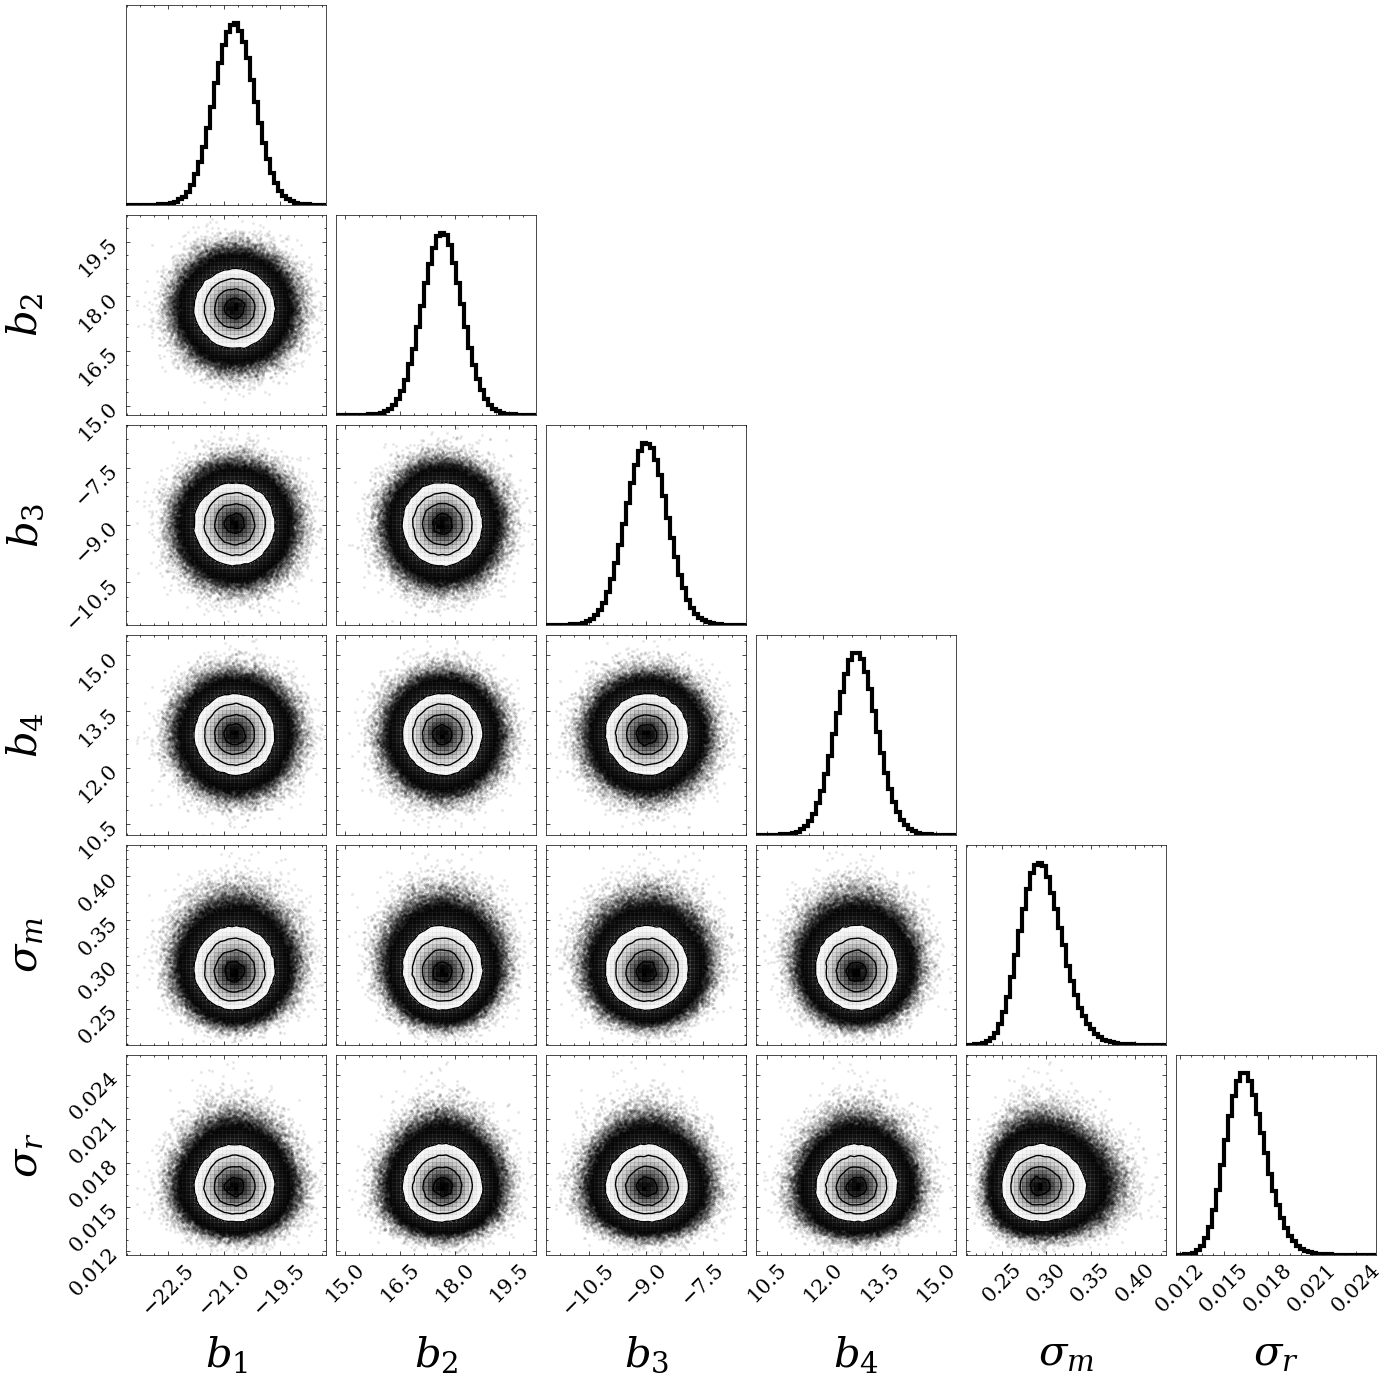

In [233]:
label = [f'$b_{i}$' for i in range(1, components_kept +1)]
label.append(f'$\sigma_m$')
label.append(f'$\sigma_r$')

plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)
figure = corner.corner(samples,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label, 
                       # truths=beta,truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)


plt.show()

In [234]:
model_weights = []
for beta in samples:
    model_weights.append(np.dot(beta[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights = np.array(model_weights)

model_weights.shape

(500000, 9)

In [235]:
filtered_model_predictions_mass = filtered_models_output_mass.iloc[:,3:-1].values

In [236]:
lower_mass, median_mass, upper_mass = rndm_m_mass_calculator(model_weights, filtered_model_predictions_mass, samples)

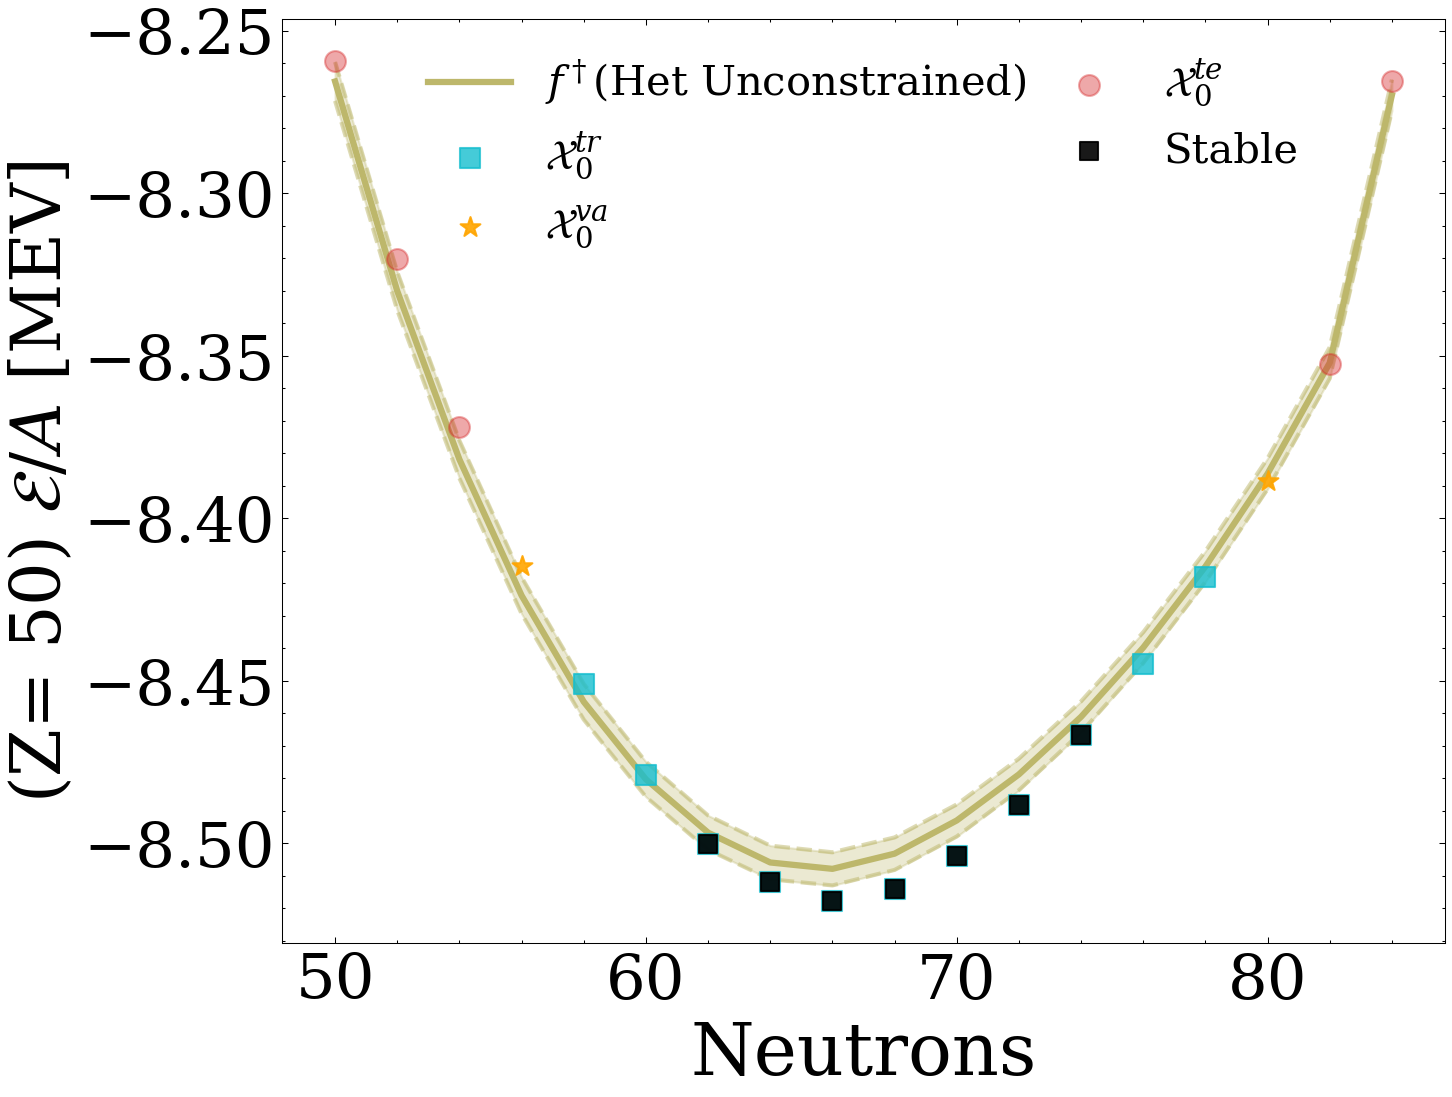

In [315]:
supermodel_predictions_mass_range = [lower_mass, median_mass, upper_mass]
savefig_50_mass = 'Plots/Heterogeneous Mass forecasts in unconstrained case for Z = 50.png'
plot_filtered_supermodel(supermodel_predictions_mass_range, filtered_models_output_mass_list, 50, 'MEV', 'E', 'Het Unconstrained', savefig_50_mass)

In [238]:
filtered_model_predictions_radius = filtered_models_output_radius.iloc[:,3:-1].values

In [239]:
lower_radius, median_radius, upper_radius = rndm_m_radius_calculator(model_weights, filtered_model_predictions_radius, samples)

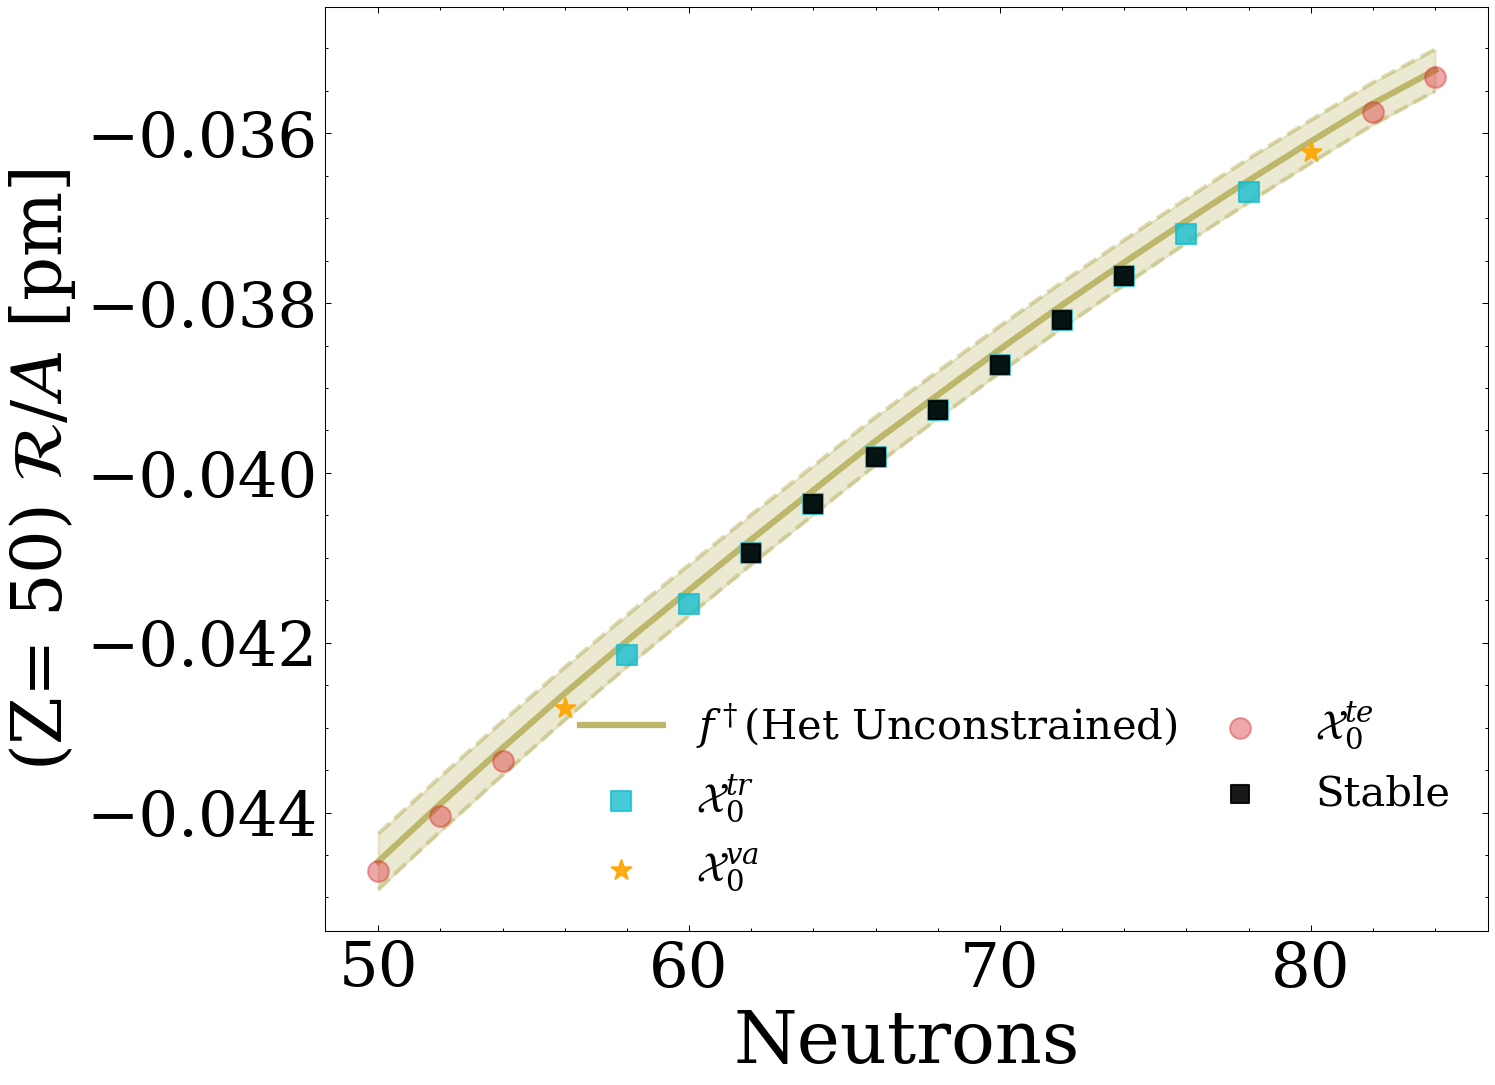

In [316]:
supermodel_predictions_radius_range = [lower_radius, median_radius, upper_radius]
savefig_50_radius = 'Plots/Heterogeneous Radius forecasts in unconstrained case for Z = 50.png'
plot_filtered_supermodel(supermodel_predictions_radius_range, filtered_models_output_radius_list, 50, 'pm', 'R', 'Het Unconstrained', savefig_50_radius)

### Simplex 

In [241]:
nu0_chosen=10
sigma20_chosen=0.5
bias0=np.full(len(model_predictions_combined_train.T),1/len(model_predictions_combined_train.T))

In [242]:
def gibbs_sampler_simplex(y, X, iterations,prior_info,burn,stepsize):
    # if centering_data == False:
    #     print("Only available for centering data")
    #     return 
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
#     b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    nu0, sigma20  =  prior_info   #Since our prior is only in \sigma, we are letting the \betas be free beyond the simplex
    
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    cov_matrix_step=np.diag(S_hat**2*stepsize**2)

    y_mass = y[:300]
    y_radius = y[300:]
    X_mass = X[:300,:]
    X_radius = X[300:,:]
    
    n = len(y_mass)
    
    #Initializing the starting point at the average of all the models
    b_current = np.full(len(X.T),0)

    
    
    supermodel_mass_current=X_mass.dot(b_current)
    supermodel_radius_current=X_radius.dot(b_current)
    

    residuals_mass_current = y_mass - supermodel_mass_current 
    residuals_radius_current = y_radius - supermodel_radius_current 

    
  
    log_likelihood_mass_current= -np.sum(residuals_mass_current**2)
    log_likelihood_radius_current= -np.sum(residuals_radius_current**2)
    
    
    sigma2_mass = -log_likelihood_mass_current/ len(residuals_mass_current) 
    sigma2_radius = -log_likelihood_radius_current/ len(residuals_radius_current)
    
    samples_beta = []
    samples_sigma2_mass = []
    samples_sigma2_radius = []
    acceptance=0
    
    for i in range(burn):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

        
            #Comment this line and uncomment the next if you want to check MCMC without the simplex  
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        
        else:
            
            supermodel_mass_proposed=X_mass.dot(b_proposed)
    
            residuals_mass_proposed = y_mass - supermodel_mass_proposed 

            log_likelihood_mass_proposed= -np.sum(residuals_mass_proposed**2)

            supermodel_radius_proposed=X_radius.dot(b_proposed)
    
            residuals_radius_proposed = y_radius - supermodel_radius_proposed 

            log_likelihood_radius_proposed= -np.sum(residuals_radius_proposed**2)
            
#           Calculate the acceptancte probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_mass_proposed - log_likelihood_mass_current)/sigma2_mass  \
                                             + (+log_likelihood_radius_proposed - log_likelihood_radius_current)/sigma2_radius   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_mass_current=log_likelihood_mass_proposed
                log_likelihood_radius_current=log_likelihood_radius_proposed
                
        shape_post = (nu0 + n)/2.
        
        
#         scale_post = (nu0*sigma20 - log_likelihood_current/len(residuals_current))/2.0
        
        scale_post_mass = (nu0*sigma20 - log_likelihood_mass_current)/2.0
        scale_post_radius = (nu0*sigma20 - log_likelihood_radius_current)/2.0
        
        sigma2_mass = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post_mass)
        sigma2_radius = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post_radius)
        
#         samples.append(np.append(b_current,np.sqrt(sigma2)))
        
        
  

    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

    #Comment this line and uncomment the next if you want to check MCMC without the simplex    
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        else:
            
            supermodel_mass_proposed=X_mass.dot(b_proposed)
    
            residuals_mass_proposed = y_mass - supermodel_mass_proposed 

            log_likelihood_mass_proposed= -np.sum(residuals_mass_proposed**2)

            supermodel_radius_proposed=X_radius.dot(b_proposed)
    
            residuals_radius_proposed = y_radius - supermodel_radius_proposed 

            log_likelihood_radius_proposed= -np.sum(residuals_radius_proposed**2)
            
#           Calculate the acceptancte probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_mass_proposed - log_likelihood_mass_current)/sigma2_mass  \
                                             + (+log_likelihood_radius_proposed - log_likelihood_radius_current)/sigma2_radius   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_mass_current=log_likelihood_mass_proposed
                log_likelihood_radius_current=log_likelihood_radius_proposed
                acceptance=acceptance+1
        samples_beta.append(b_current)
        
        shape_post = (nu0 + n)/2.
        
        
#         scale_post = (nu0*sigma20 - log_likelihood_current/len(residuals_current))/2.0
        
        scale_post_mass = (nu0*sigma20 - log_likelihood_mass_current)/2.0
        scale_post_radius = (nu0*sigma20 - log_likelihood_radius_current)/2.0
        
        sigma2_mass = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post_mass)
        sigma2_radius = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post_radius)

        samples_sigma2_mass.append(sigma2_mass)
        samples_sigma2_radius.append(sigma2_radius) 

    
    samples_beta = np.array(samples_beta)
    samples_sigma2_mass = np.array(samples_sigma2_mass).reshape(iterations,1)
    samples_sigma2_radius = np.array(samples_sigma2_radius).reshape(iterations,1)

    samples = np.hstack((samples_beta, samples_sigma2_mass, samples_sigma2_radius))       
        
        
        
    

    print("percentage accepted:", round(acceptance/iterations*100))
    return  samples

In [243]:
%%time
samples_simplex=gibbs_sampler_simplex(y, X, 500000,[nu0_chosen, sigma20_chosen],burn=300000,stepsize=0.001)

percentage accepted: 45
CPU times: total: 3min 26s
Wall time: 4min 50s


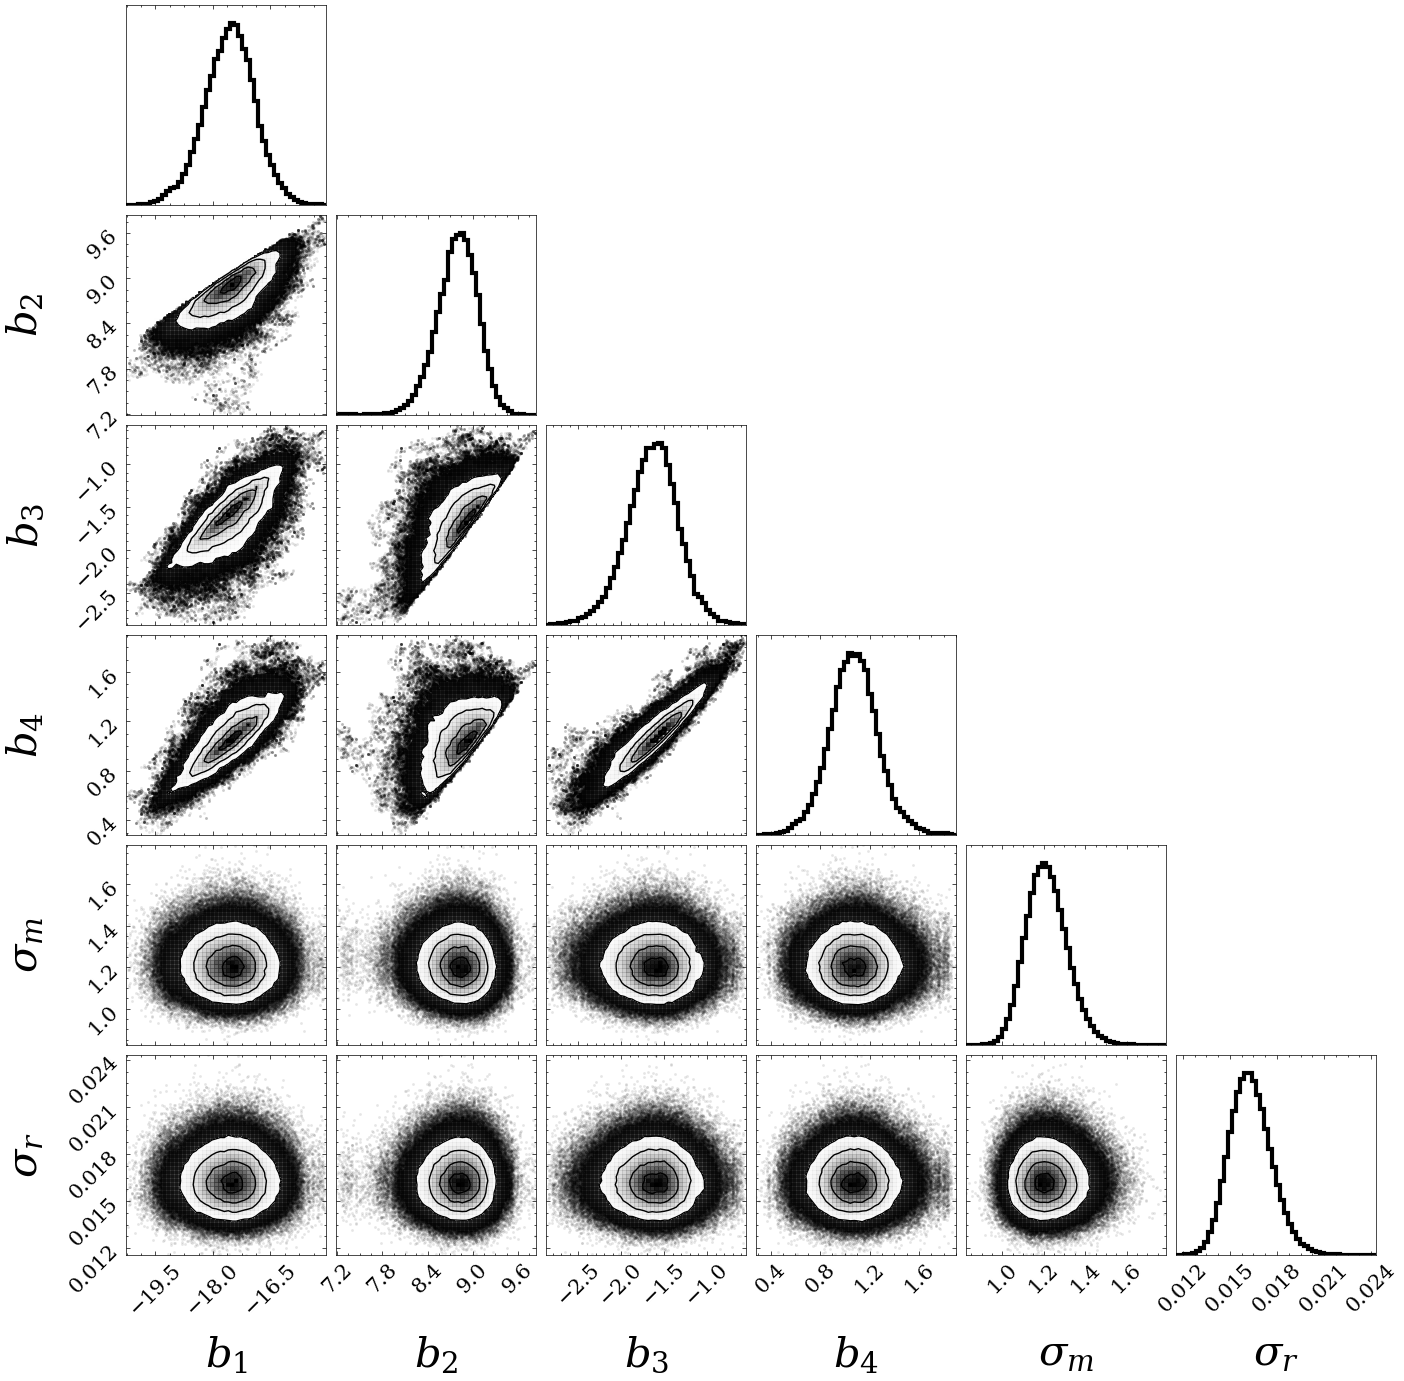

In [244]:
label = [f'$b_{i}$' for i in range(1, components_kept +1)]
label.append(f'$\sigma_m$')
label.append(f'$\sigma_r$')

plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)
figure = corner.corner(samples_simplex,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label, 
                       # truths=beta,truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)


plt.show()

In [245]:
model_weights_simplex = []
for beta in samples_simplex:
    model_weights_simplex.append(np.dot(beta[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights_simplex = np.array(model_weights_simplex)

model_weights_simplex.shape

(500000, 9)

In [246]:
filtered_model_predictions_mass = filtered_models_output_mass.iloc[:,3:-1].values
filtered_model_predictions_radius = filtered_models_output_radius.iloc[:,3:-1].values

lower_mass_simplex, median_mass_simplex, upper_mass_simplex = rndm_m_mass_calculator(model_weights_simplex, filtered_model_predictions_mass, samples_simplex)
lower_radius_simplex, median_radius_simplex, upper_radius_simplex = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_radius, samples_simplex)

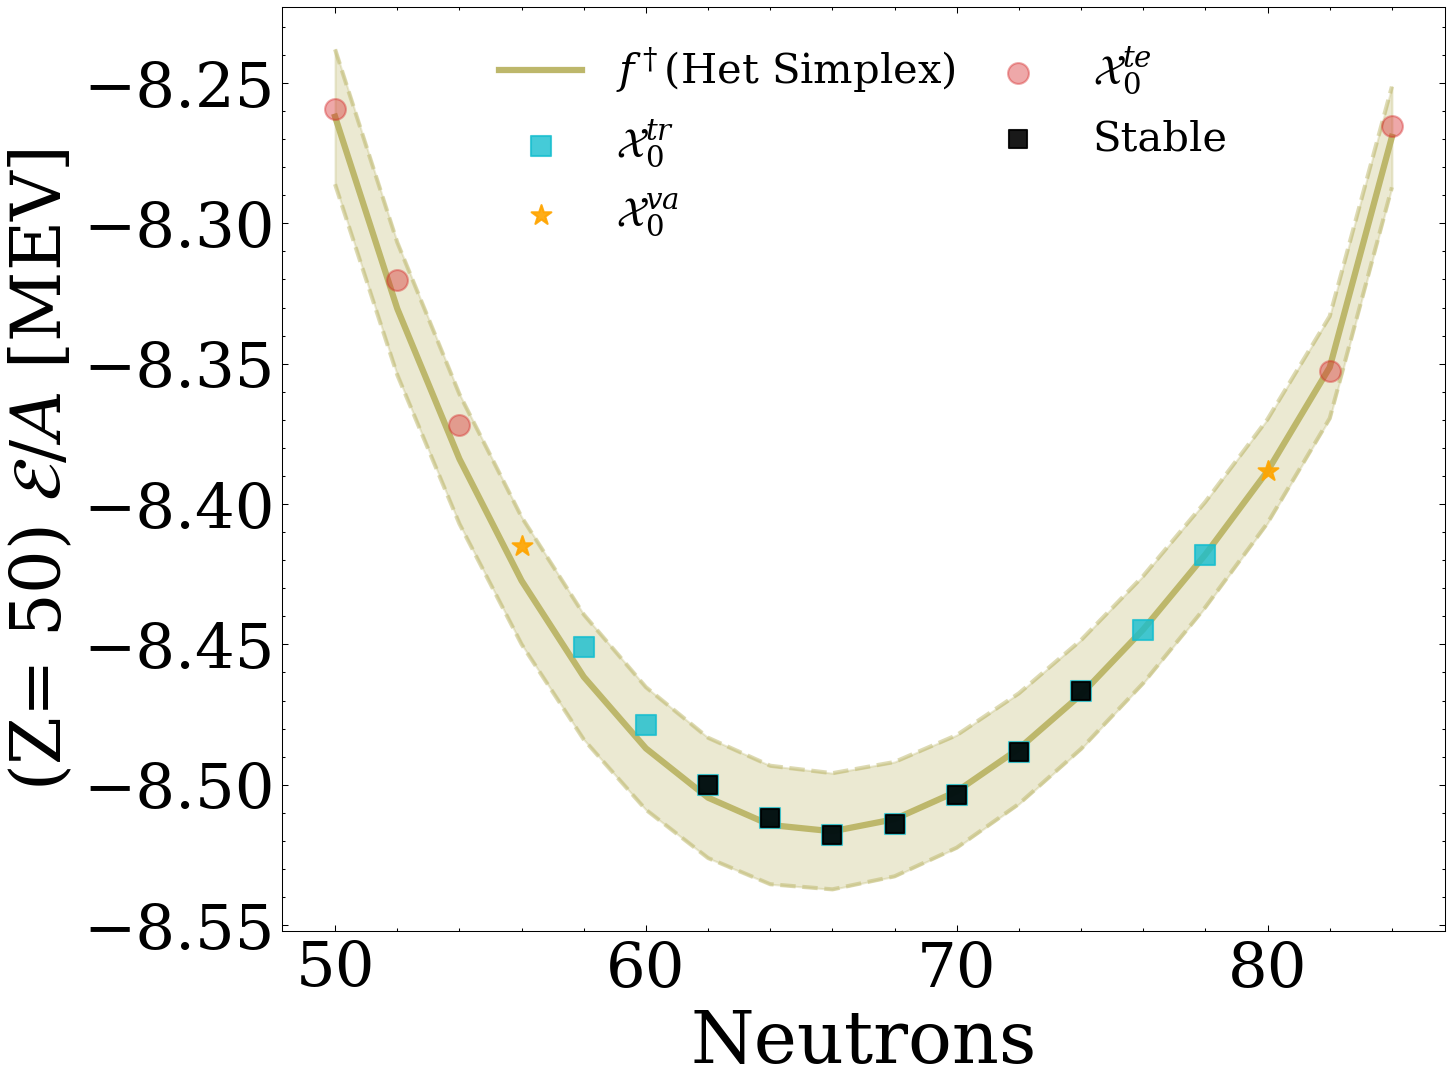

In [317]:
supermodel_predictions_mass_range_simplex = [lower_mass_simplex, median_mass_simplex, upper_mass_simplex]
savefig_50_mass_simplex = 'Plots/Heterogeneous Mass forecasts in simplex case for Z = 50.png'
plot_filtered_supermodel(supermodel_predictions_mass_range_simplex, filtered_models_output_mass_list, 50, 'MEV', 'E', 'Het Simplex', savefig_50_mass_simplex)

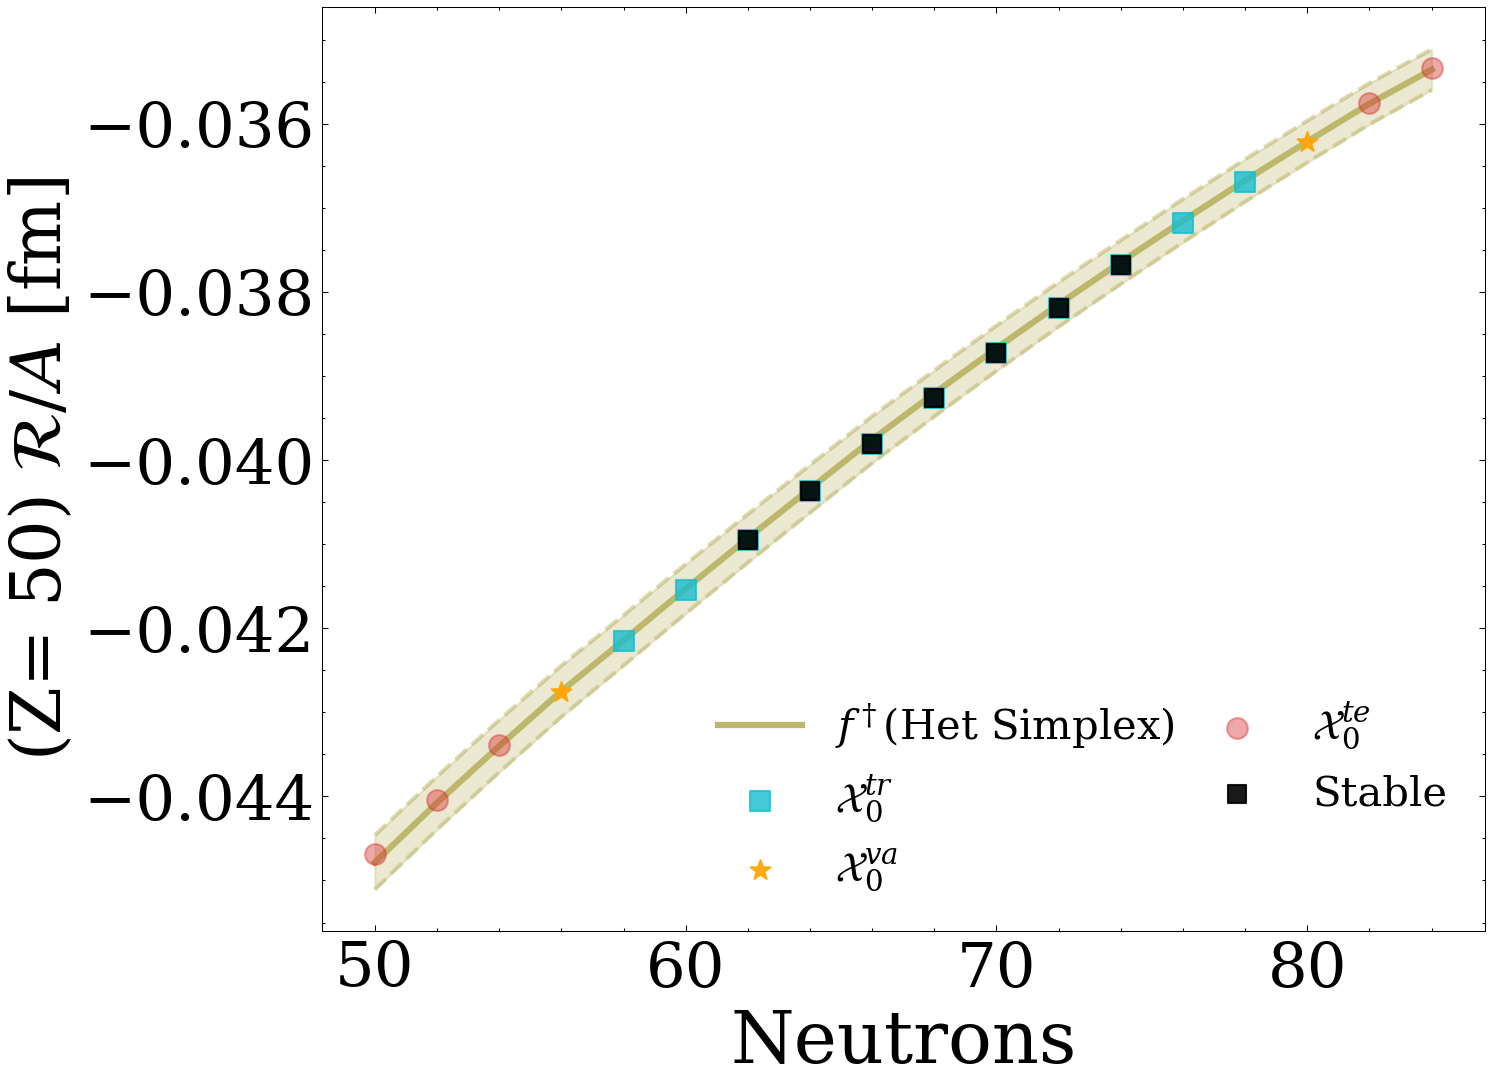

In [381]:
supermodel_predictions_radius_range_simplex = [lower_radius_simplex, median_radius_simplex, upper_radius_simplex]
savefig_50_radius_simplex = 'Plots/Heterogeneous Radius forecasts in simplex case for Z = 50.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_simplex, filtered_models_output_radius_list, 50, 'fm', 'R', 'Het Simplex', savefig_50_radius_simplex)

# Z = 60

In [249]:
filtered_models_output_mass_list_60 = filtered_models_output(60, models_output_mass_list)
filtered_models_output_radius_list_60 = filtered_models_output(60, models_output_radius_list)

filtered_models_output_mass_60 = filtered_models_output_mass_list_60[0]
filtered_models_output_radius_60 = filtered_models_output_radius_list_60[0]

filtered_model_predictions_mass_60 = filtered_models_output_mass_60.iloc[:,3:-1].values
filtered_model_predictions_radius_60 = filtered_models_output_radius_60.iloc[:,3:-1].values

In [250]:
lower_mass_simplex_60, median_mass_simplex_60, upper_mass_simplex_60 = rndm_m_mass_calculator(model_weights_simplex, filtered_model_predictions_mass_60, samples_simplex)
lower_radius_simplex_60, median_radius_simplex_60, upper_radius_simplex_60 = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_radius_60, samples_simplex)

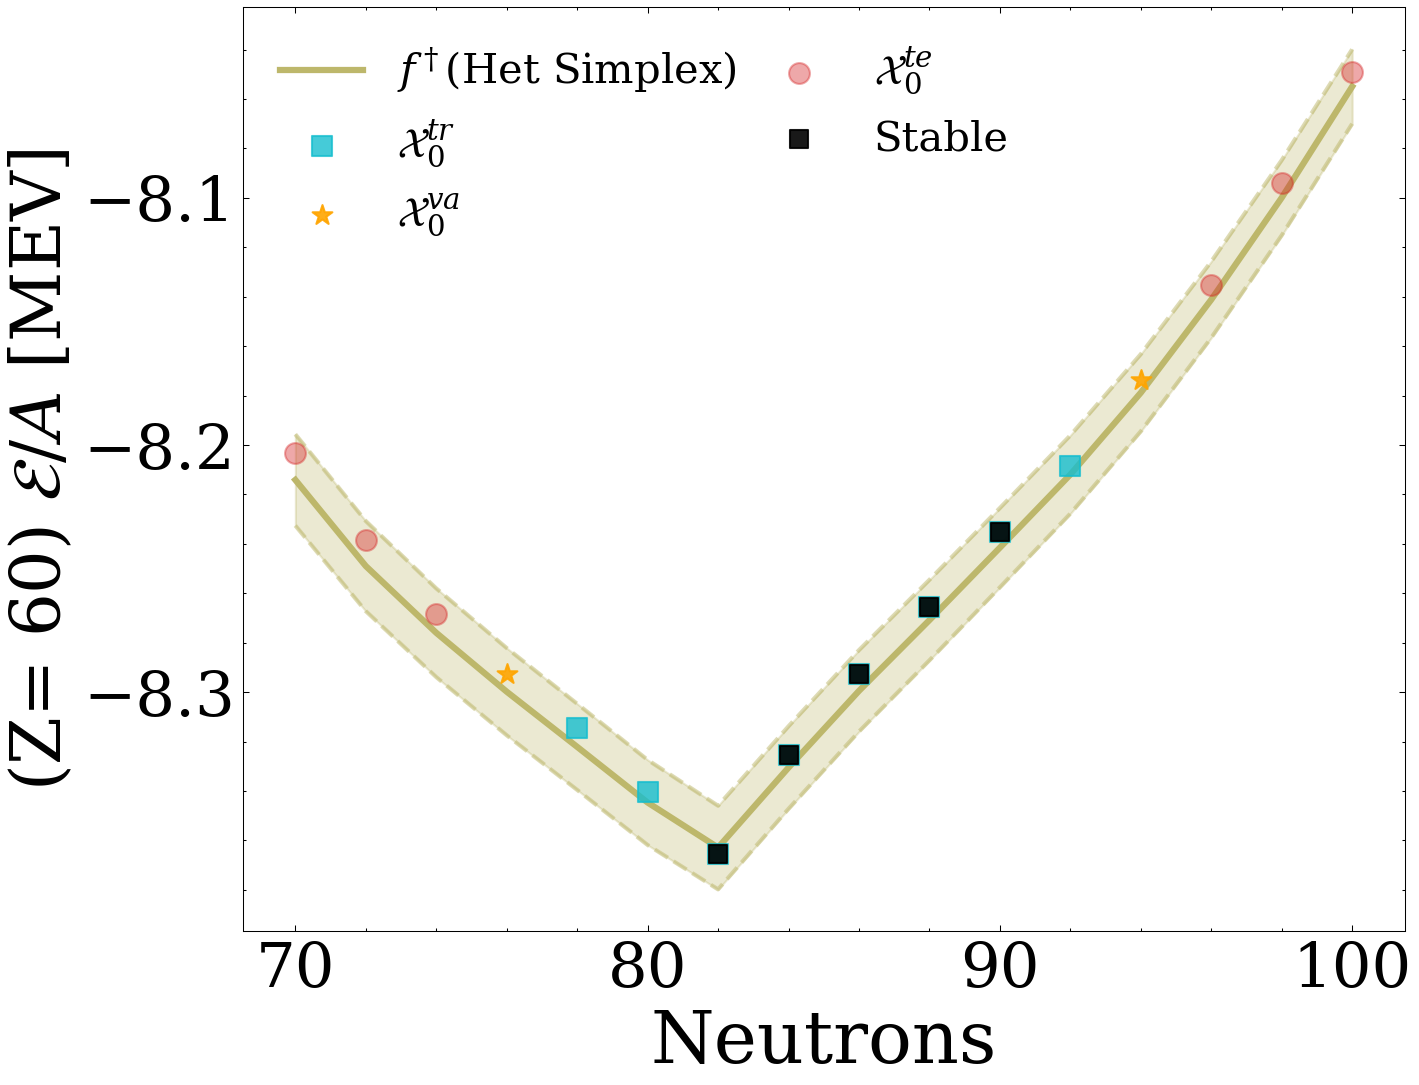

In [319]:
supermodel_predictions_mass_range_simplex_60 = [lower_mass_simplex_60, median_mass_simplex_60, upper_mass_simplex_60]
savefig_60_mass_simplex = 'Plots/Heterogeneous Mass forecasts in simplex case for Z = 60.png'
plot_filtered_supermodel(supermodel_predictions_mass_range_simplex_60, filtered_models_output_mass_list_60, 60, 'MEV', 'E', 'Het Simplex', savefig_60_mass_simplex)

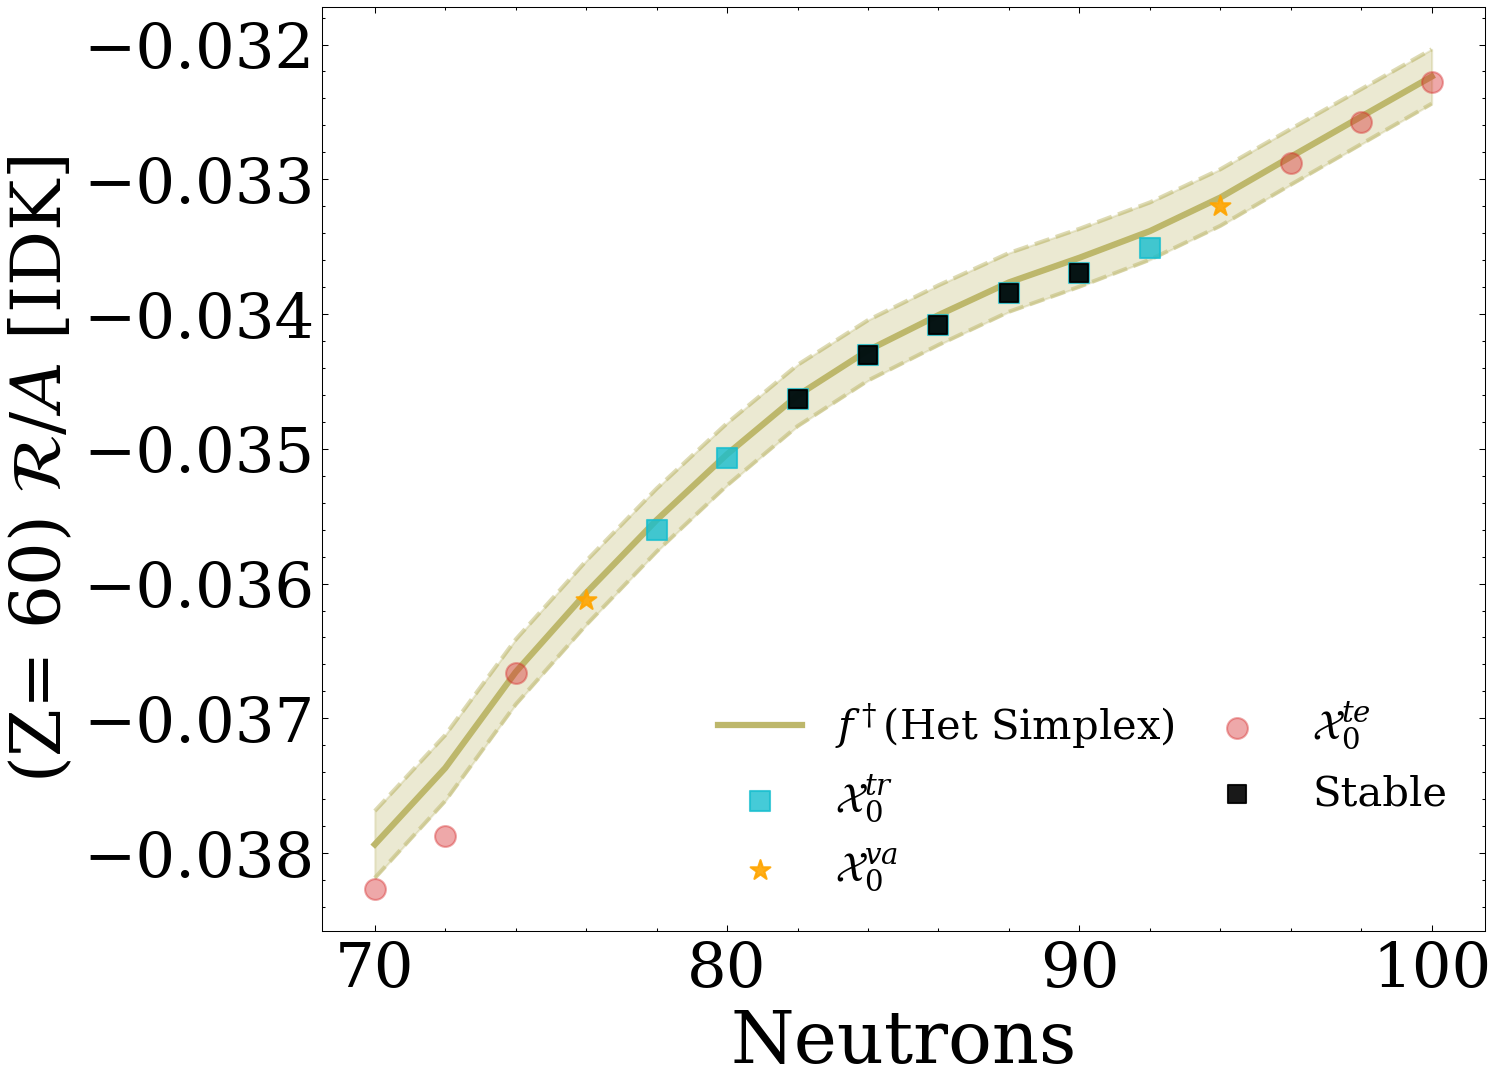

In [320]:
supermodel_predictions_radius_range_simplex_60 = [lower_radius_simplex_60, median_radius_simplex_60, upper_radius_simplex_60]
savefig_60_radius_simplex = 'Plots/Heterogeneous Radius forecasts in simplex case for Z = 60.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_simplex_60, filtered_models_output_radius_list_60, 60, 'IDK', 'R', 'Het Simplex', savefig_60_radius_simplex)

# Z = 70

In [253]:
filtered_models_output_mass_list_70 = filtered_models_output(70, models_output_mass_list)
filtered_models_output_radius_list_70 = filtered_models_output(70, models_output_radius_list)

filtered_models_output_mass_70 = filtered_models_output_mass_list_70[0]
filtered_models_output_radius_70 = filtered_models_output_radius_list_70[0]

filtered_model_predictions_mass_70 = filtered_models_output_mass_70.iloc[:,3:-1].values
filtered_model_predictions_radius_70 = filtered_models_output_radius_70.iloc[:,3:-1].values

In [254]:
lower_mass_simplex_70, median_mass_simplex_70, upper_mass_simplex_70 = rndm_m_mass_calculator(model_weights_simplex, filtered_model_predictions_mass_70, samples_simplex)
lower_radius_simplex_70, median_radius_simplex_70, upper_radius_simplex_70 = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_radius_70, samples_simplex)

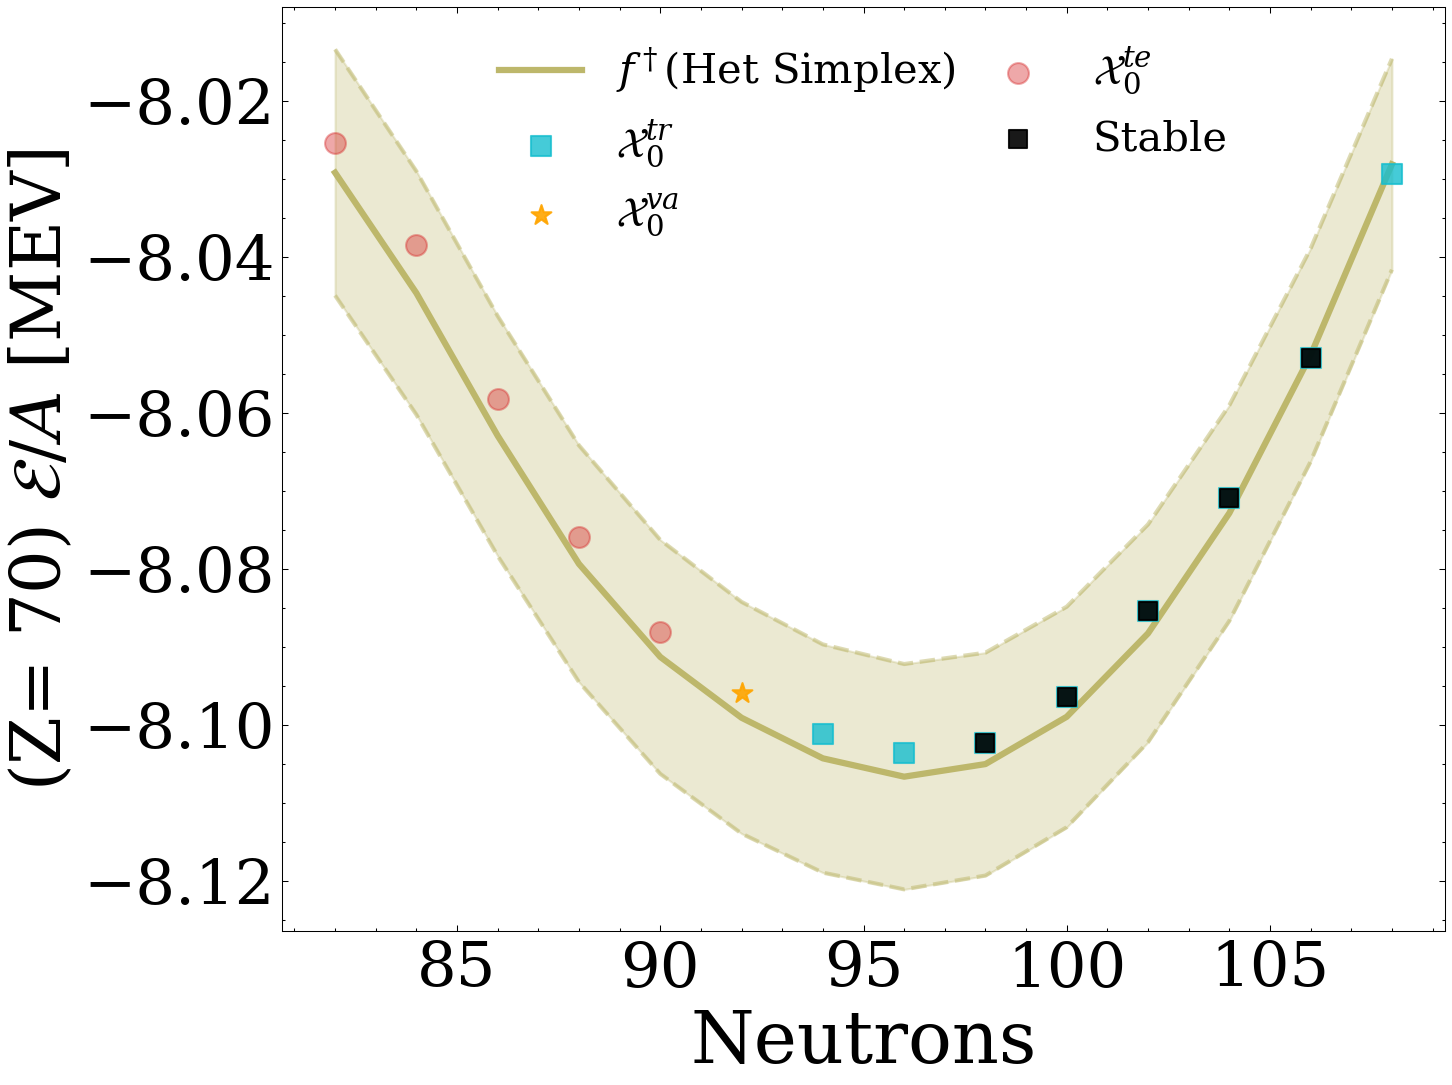

In [321]:
supermodel_predictions_mass_range_simplex_70 = [lower_mass_simplex_70, median_mass_simplex_70, upper_mass_simplex_70]
savefig_70_mass_simplex = 'Plots/Heterogeneous Mass forecasts in simplex case for Z = 70.png'
plot_filtered_supermodel(supermodel_predictions_mass_range_simplex_70, filtered_models_output_mass_list_70, 70, 'MEV', 'E', 'Het Simplex', savefig_70_mass_simplex)

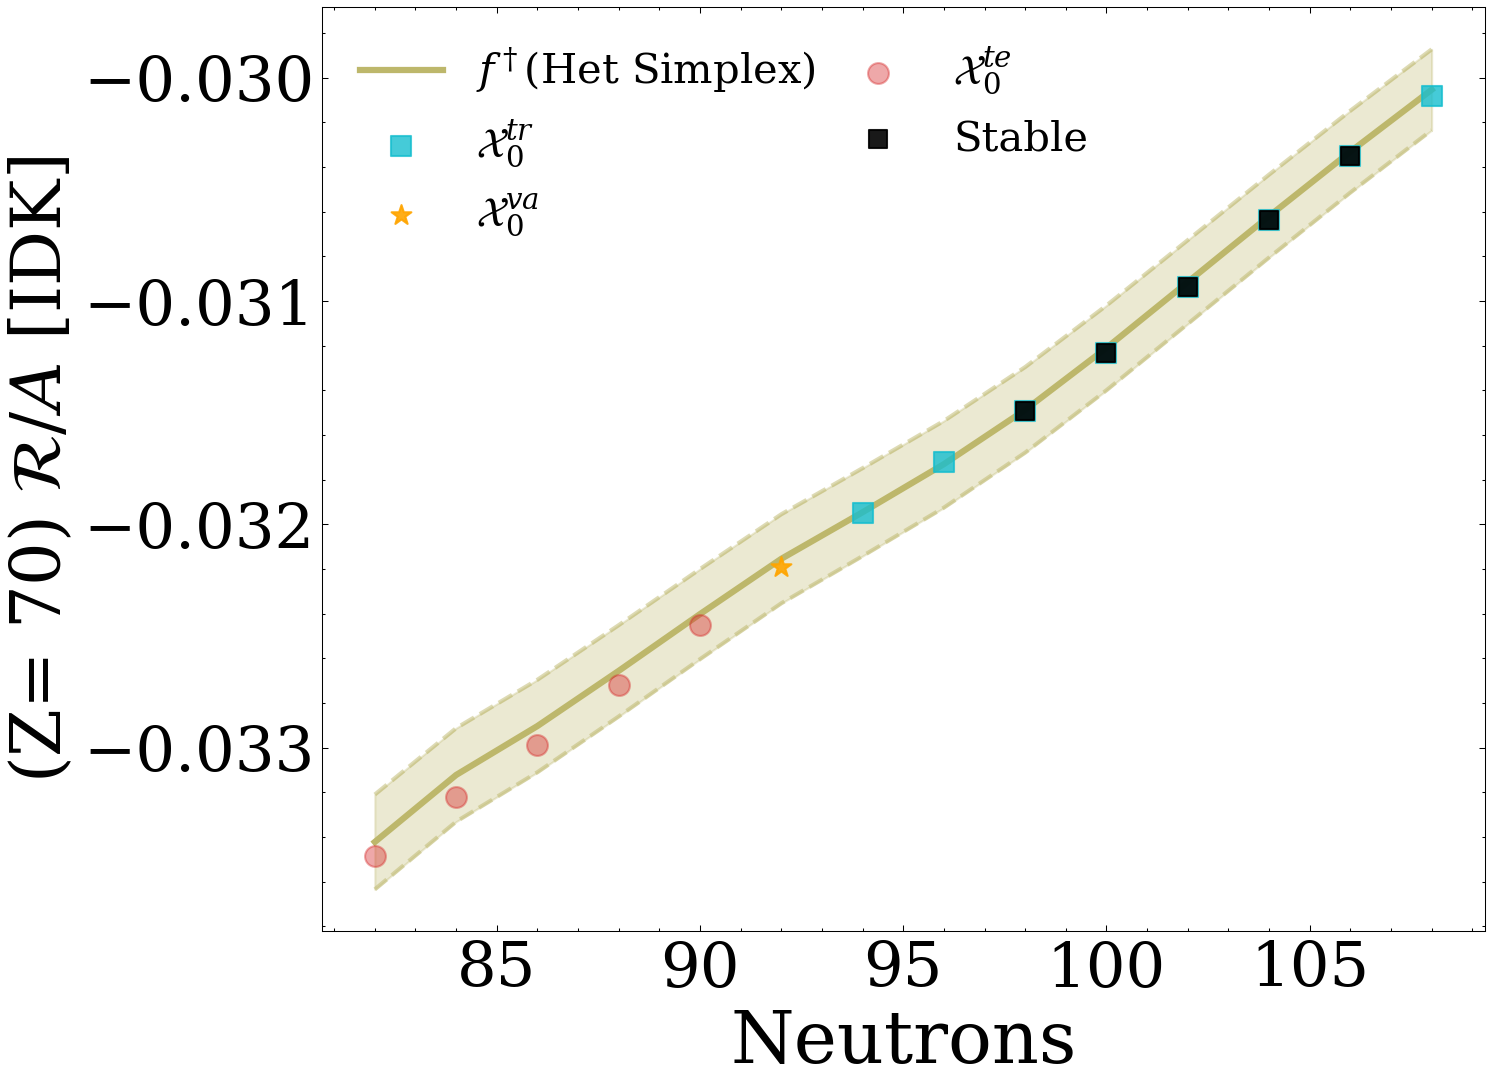

In [322]:
supermodel_predictions_radius_range_simplex_70 = [lower_radius_simplex_70, median_radius_simplex_70, upper_radius_simplex_70]
savefig_70_radius_simplex = 'Plots/Heterogeneous Radius forecasts in simplex case for Z = 70.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_simplex_70, filtered_models_output_radius_list_70, 70, 'IDK', 'R', 'Het Simplex', savefig_70_radius_simplex)

# Z = 80

In [257]:
filtered_models_output_mass_list_80 = filtered_models_output(80, models_output_mass_list)
filtered_models_output_radius_list_80 = filtered_models_output(80, models_output_radius_list)

filtered_models_output_mass_80 = filtered_models_output_mass_list_80[0]
filtered_models_output_radius_80 = filtered_models_output_radius_list_80[0]

filtered_model_predictions_mass_80 = filtered_models_output_mass_80.iloc[:,3:-1].values
filtered_model_predictions_radius_80 = filtered_models_output_radius_80.iloc[:,3:-1].values

In [258]:
lower_mass_simplex_80, median_mass_simplex_80, upper_mass_simplex_80 = rndm_m_mass_calculator(model_weights_simplex, filtered_model_predictions_mass_80, samples_simplex)
lower_radius_simplex_80, median_radius_simplex_80, upper_radius_simplex_80 = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_radius_80, samples_simplex)

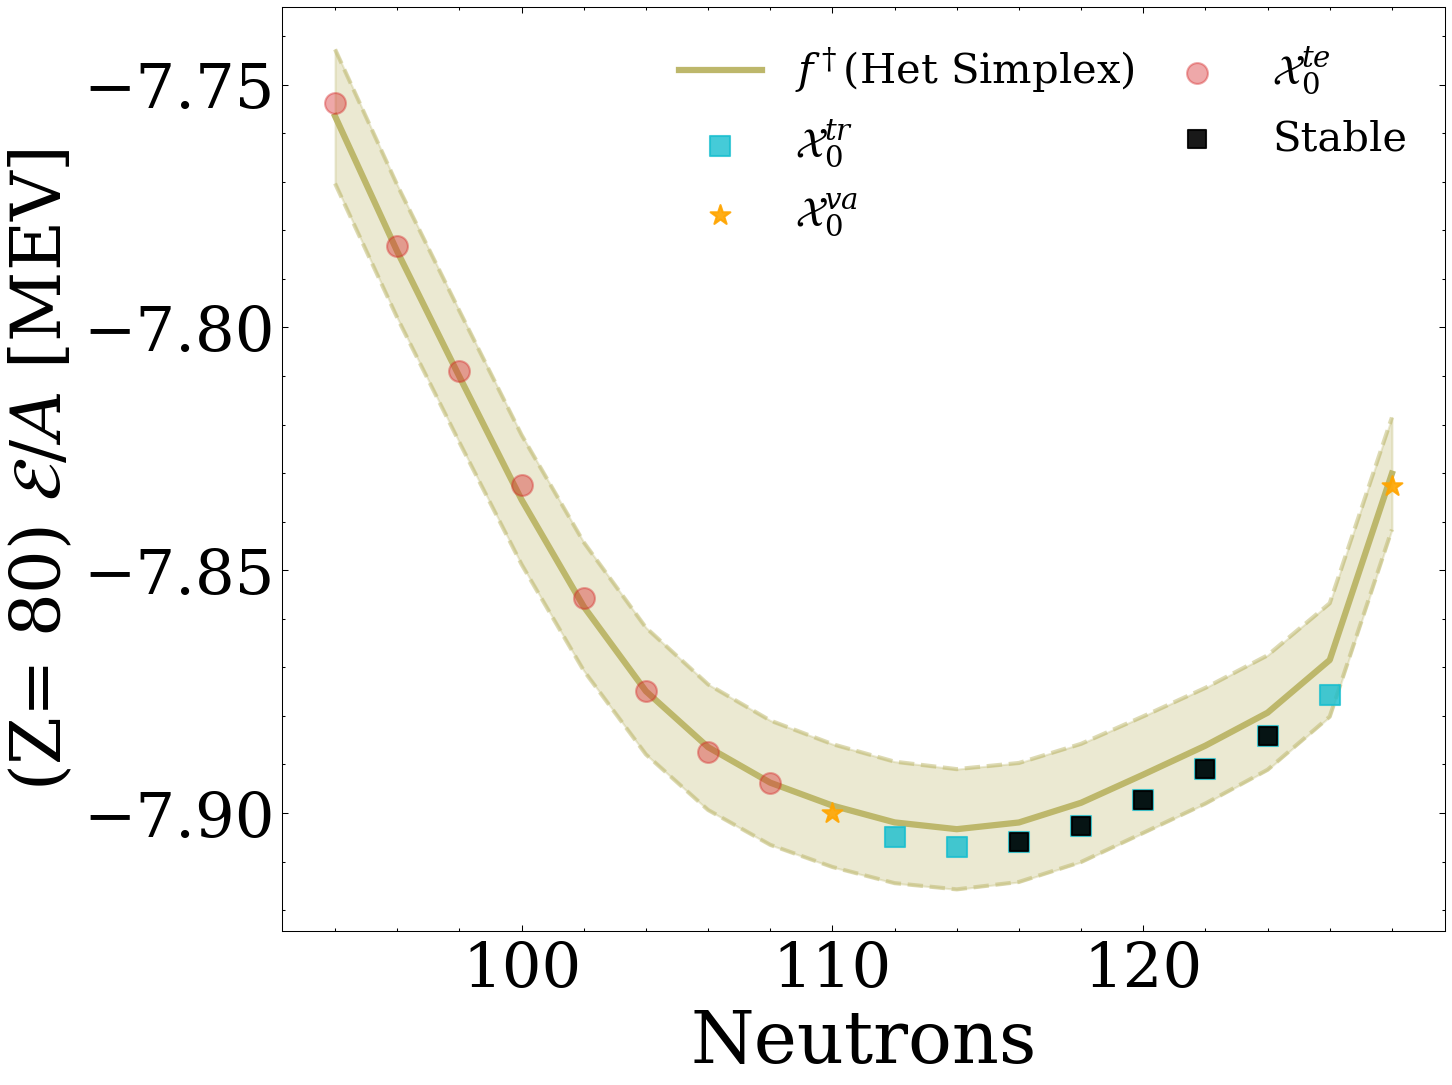

In [323]:
supermodel_predictions_mass_range_simplex_80 = [lower_mass_simplex_80, median_mass_simplex_80, upper_mass_simplex_80]
savefig_80_mass_simplex = 'Plots/Heterogeneous Mass forecasts in simplex case for Z = 80.png'
plot_filtered_supermodel(supermodel_predictions_mass_range_simplex_80, filtered_models_output_mass_list_80, 80, 'MEV', 'E', 'Het Simplex', savefig_80_mass_simplex)

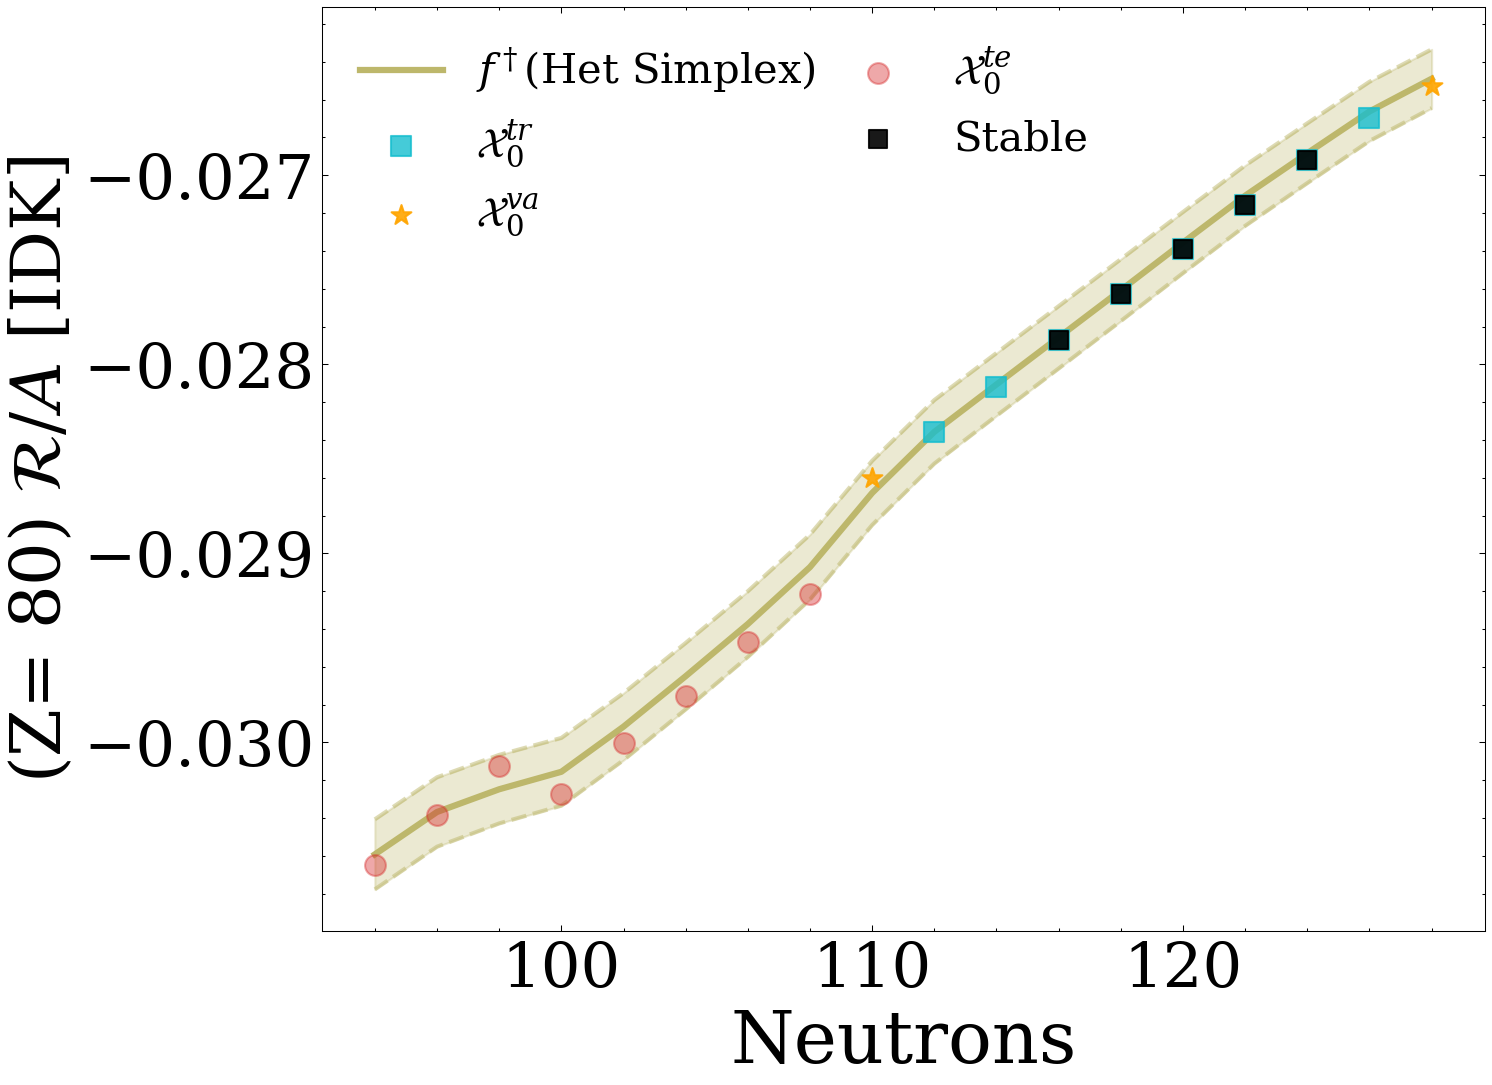

In [324]:
supermodel_predictions_radius_range_simplex_80 = [lower_radius_simplex_80, median_radius_simplex_80, upper_radius_simplex_80]
savefig_80_radius_simplex = 'Plots/Heterogeneous Radius forecasts in simplex case for Z = 80.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_simplex_80, filtered_models_output_radius_list_80, 80, 'IDK', 'R', 'Het Simplex', savefig_80_radius_simplex)

## The next step is to compare the performance of the coverage graph in both radius and mass with respect to our mass-only analysis

In [261]:
rndm_m_full_mass_train_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_train, 5000, Vt_hat)

100%|██████████| 5000/5000 [01:20<00:00, 62.21it/s] 


In [262]:
rndm_m_full_mass_train_simplex.shape

(5000, 300)

In [263]:
rndm_m_full_mass_validation_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_validation, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:05<00:00, 970.17it/s]


In [264]:
rndm_m_full_mass_test_simplex = rndm_m_mass_calculator_coverage(samples_simplex, model_predictions_mass_test, 5000, Vt_hat)

100%|██████████| 5000/5000 [01:07<00:00, 74.40it/s]


In [265]:
rndm_m_full_radius_train_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_train, 5000, Vt_hat)

100%|██████████| 5000/5000 [01:21<00:00, 61.54it/s]


In [266]:
rndm_m_full_radius_validation_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_validation, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:05<00:00, 897.91it/s]


In [267]:
rndm_m_full_radius_test_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_test, 5000, Vt_hat)

100%|██████████| 5000/5000 [01:05<00:00, 76.68it/s]


In [268]:
coverage_mass_train_simplex = coverage_calculation(rndm_m_full_mass_train_simplex, models_output_mass_train)

In [269]:
coverage_mass_validation_simplex = coverage_calculation(rndm_m_full_mass_validation_simplex, models_output_mass_validation)

In [270]:
coverage_mass_test_simplex = coverage_calculation(rndm_m_full_mass_test_simplex, models_output_mass_test)

In [271]:
percentiles = np.arange(0,101,5)

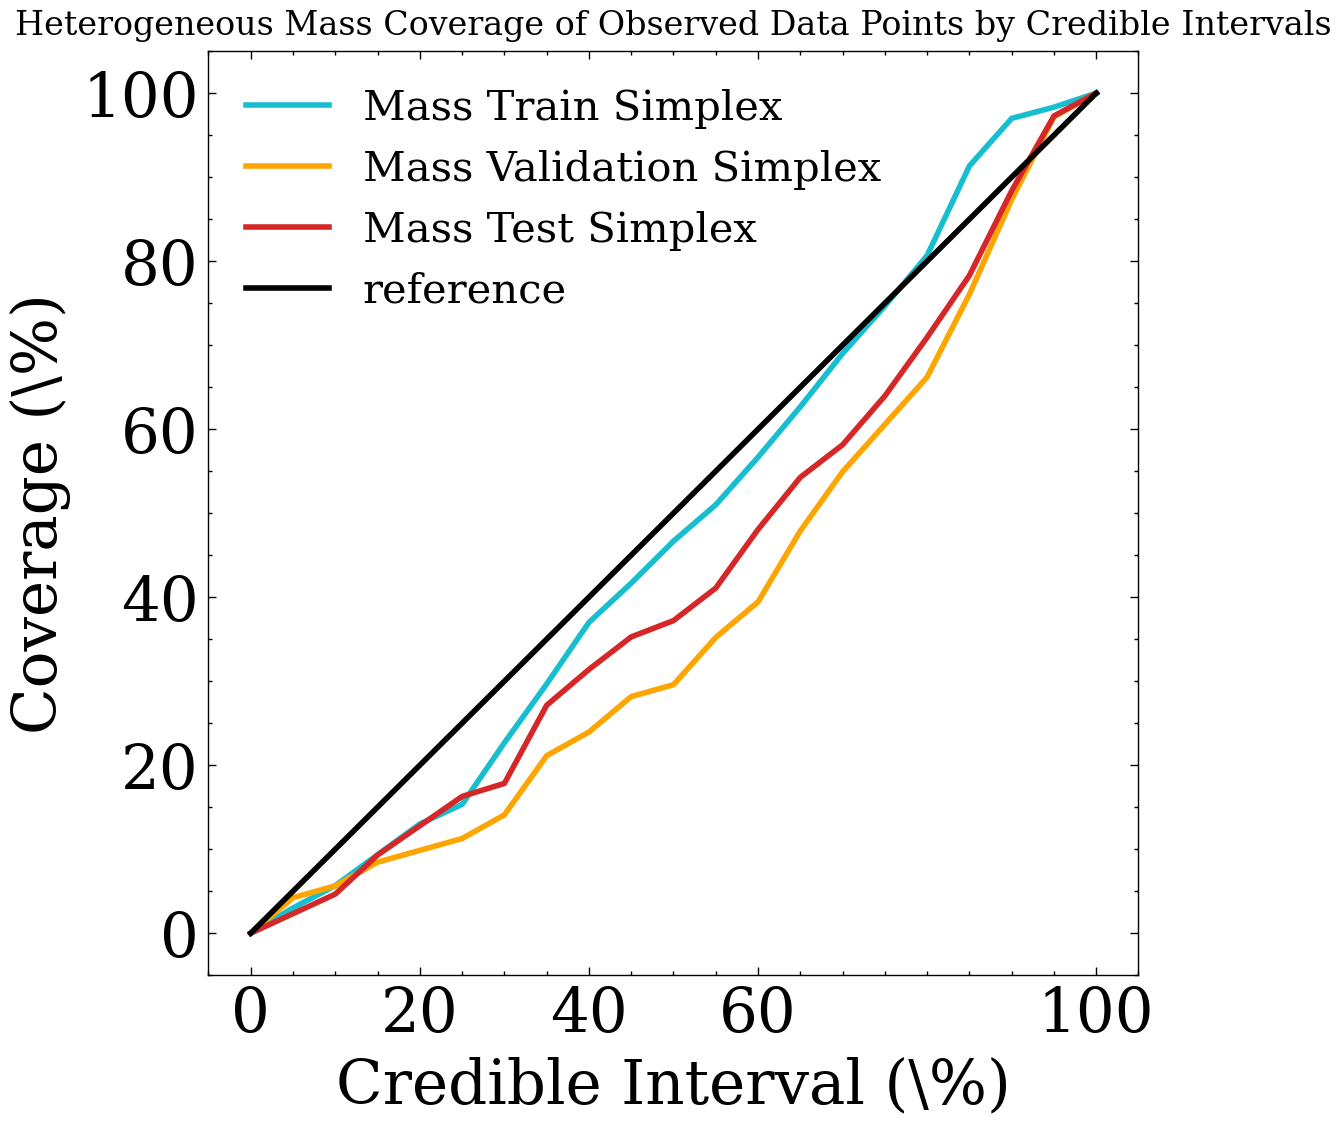

In [302]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_mass_train_simplex, label='Mass Train Simplex',color=color_trainig,linewidth=width_line)
plt.plot(percentiles, coverage_mass_validation_simplex, label='Mass Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_mass_test_simplex, label='Mass Test Simplex',color=color_testing,linewidth=width_line)


# plt.plot(percentiles, coverage_train_simplex,linestyle='dashed', label='Training',color=color_trainig,linewidth=width_line)
# plt.plot(percentiles, coverage_validation_simplex, linestyle='dashed',label='Validation',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_test_simplex,linestyle='dashed', label='Test',color=color_testing,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=width_line)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,100])

plt.title('Heterogeneous Mass Coverage of Observed Data Points by Credible Intervals')
# plt.grid(True)
plt.legend(fontsize=15)
plt.savefig('Plots/Heterogeneous Mass Coverage Graph of simplex case.png')
plt.show()

In [273]:
coverage_radius_train_simplex = coverage_calculation(rndm_m_full_radius_train_simplex, models_output_radius_train)

In [274]:
coverage_radius_validation_simplex = coverage_calculation(rndm_m_full_radius_validation_simplex, models_output_radius_validation)

In [275]:
coverage_radius_test_simplex = coverage_calculation(rndm_m_full_radius_test_simplex, models_output_radius_test)

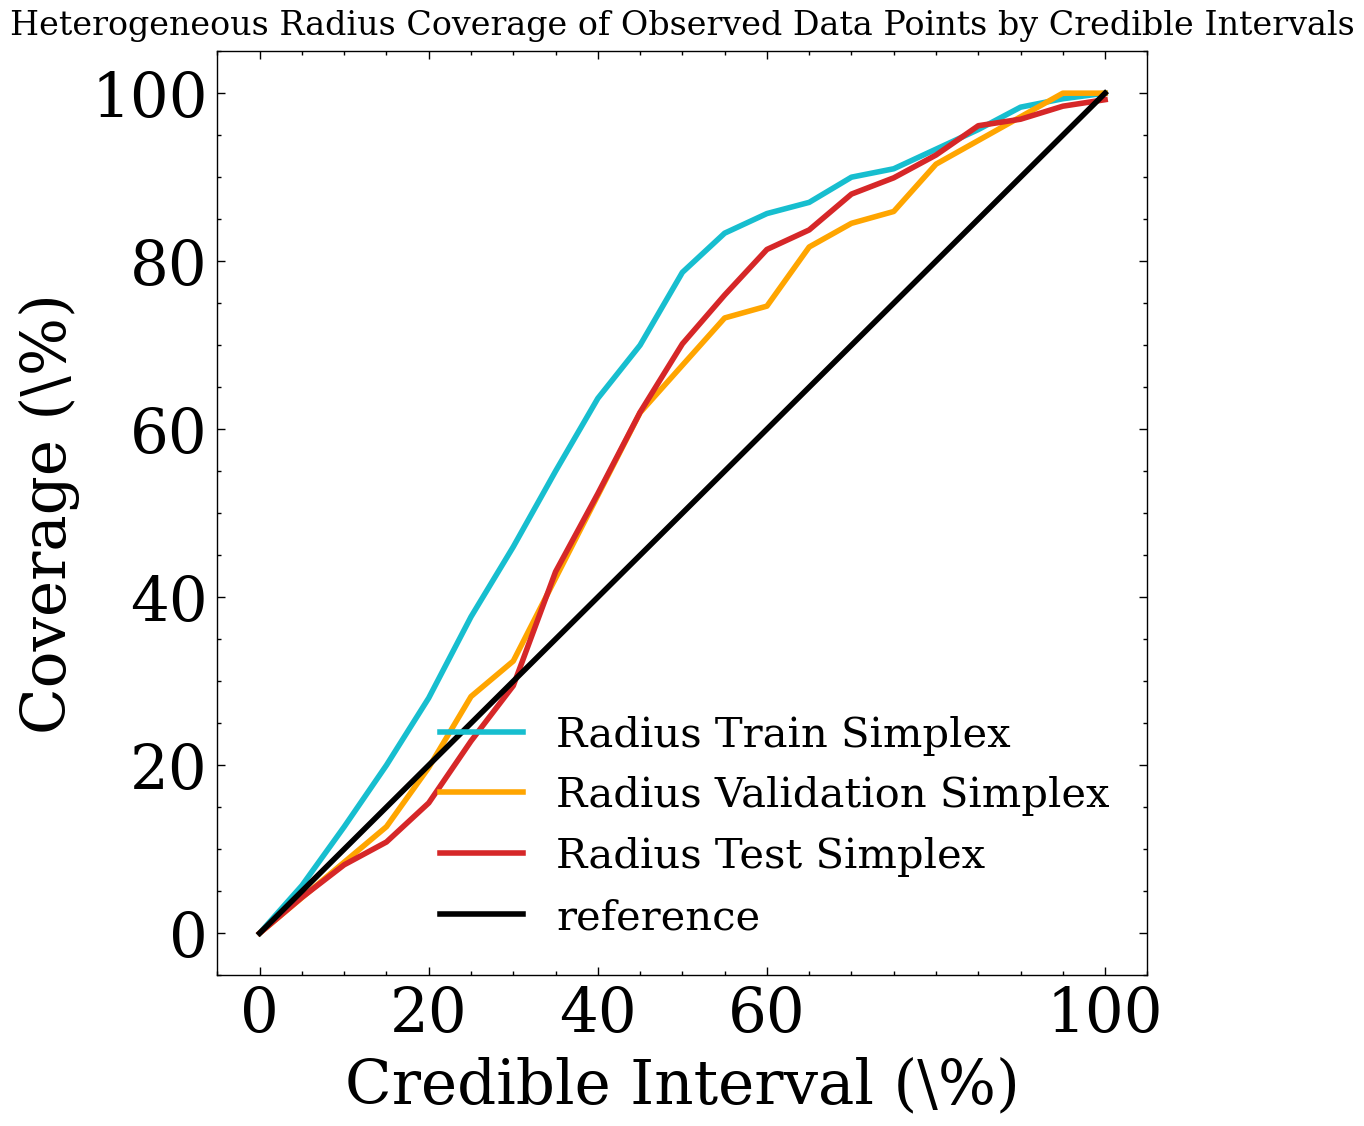

In [325]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_radius_train_simplex, label='Radius Train Simplex',color=color_trainig,linewidth=width_line)
plt.plot(percentiles, coverage_radius_validation_simplex, label='Radius Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_radius_test_simplex, label='Radius Test Simplex',color=color_testing,linewidth=width_line)


# plt.plot(percentiles, coverage_train_simplex,linestyle='dashed', label='Training',color=color_trainig,linewidth=width_line)
# plt.plot(percentiles, coverage_validation_simplex, linestyle='dashed',label='Validation',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_test_simplex,linestyle='dashed', label='Test',color=color_testing,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=width_line)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,100])

plt.title('Heterogeneous Radius Coverage of Observed Data Points by Credible Intervals')
# plt.grid(True)
plt.legend(fontsize=15)
plt.savefig('Plots/Heterogeneous Radius Coverage Graph of simplex case.png')
plt.show()

In [374]:
def PC_RMSE_calculator(components_kept, predictions_mean_list, models_output_list, model_predictions_list):  #A function that will basically run everything above (without the plots) with varying number of kept PCs

    predictions_mean = predictions_mean_list[0]
    predictions_mean_train = predictions_mean_list[1]
    predictions_mean_validation = predictions_mean_list[2]
    predictions_mean_test = predictions_mean_list[3]

    models_output = models_output_list[0]
    models_output_train = models_output_list[1]
    models_output_validation = models_output_list[2]
    models_output_test = models_output_list[3]

    model_predictions = model_predictions_list[0]
    model_predictions_train = model_predictions_list[1]
    model_predictions_validation = model_predictions_list[2]
    model_predictions_test = model_predictions_list[3]

    S_hat=np.array([S[i] for i in range(components_kept)])

    # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
    U_hat=np.array([U.T[i] for i in range(components_kept)])

    # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
    Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)])   


    if centering_data:
        num_components=components_kept+1
    else:
        num_components=components_kept



    #########################################
    #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
    models_PC_train = {}
    if centering_data:
        models_PC_train[str("PC_0")] = predictions_mean_train       
    for i in range(components_kept):
        models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_train.T)
    models_PC_train["N"] = models_output_train["N"]
    models_PC_train["Z"] = models_output_train["Z"]
    models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
    # models_PC_training = pd.DataFrame(models_PC_train)
    models_PC_train = pd.DataFrame(models_PC_train)
    #########################################

    #########################################
    #Creating principal components that are for validation
    models_PC_validation = {}
    if centering_data:
        models_PC_validation[str("PC_0")] = predictions_mean_validation
    for i in range(components_kept):
        models_PC_validation[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_validation.T)
    models_PC_validation["N"] = models_output_validation["N"]
    models_PC_validation["Z"] = models_output_validation["Z"]
    models_PC_validation["A"] = models_PC_validation["N"] + models_PC_validation["Z"]
    models_PC_validation = pd.DataFrame(models_PC_validation)
    #########################################

    #########################################
    #Creating principal components that are for testing
    models_PC_testing = {}
    if centering_data:
        models_PC_testing[str("PC_0")] = predictions_mean_test
    for i in range(components_kept):
        # models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)*S_hat[i]
        models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)

    models_PC_testing["N"] = models_output_test["N"]
    models_PC_testing["Z"] = models_output_test["Z"]
    models_PC_testing["A"] = models_PC_testing["N"] + models_PC_testing["Z"]
    models_PC_testing = pd.DataFrame(models_PC_testing)
    #########################################

    #Creating principal components that are valid everywhere (testing + training + validation)
    models_PC = {}
    if centering_data:
        models_PC[str("PC_0")] = predictions_mean
    for i in range(components_kept):
        models_PC[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions.T)
    models_PC = pd.DataFrame(models_PC)
    models_PC["N"] = Full_set.T[0]
    models_PC["Z"] = Full_set.T[1]
    models_PC["A"] = models_PC["N"] + models_PC["Z"]
    #########################################

    key_list_PCs=list(models_PC_testing.keys())


    X=np.copy(U_hat)
    if centering_data:
        y=np.copy(models_output_train["truth"].tolist())-predictions_mean_train
    else:
        y=np.copy(models_output_train["truth"].tolist())
    #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
    X_train=[]
    for i in range(num_components):
        X_train.append(models_PC_train[key_list_PCs[i]].tolist())
    X_train=np.array(X_train)
    #Making the list of principal components across the validation part
    X_validation=[]
    for i in range(num_components):
        X_validation.append(models_PC_validation[key_list_PCs[i]].tolist())
    X_validation=np.array(X_validation)

    #Making the list of principal components across the testing part
    X_test=[]
    for i in range(num_components):
        X_test.append(models_PC_testing[key_list_PCs[i]].tolist())
    X_test=np.array(X_test)
    #Making the list of principal components across the entire chart (training+validation+testing)
    X_full=[]
    for i in range(num_components):
        X_full.append(models_PC[key_list_PCs[i]].tolist())
    X_full=np.array(X_full)

    X_train_centered = X_train[1:,:]

    # 1) Find the least square solution for the training part
    X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
    beta = X_T_X_inv.dot(X_train_centered).dot(y)
    
    #1.5) Construct the super model across the entire range and the test range
    if centering_data:
        beta_full= np.insert(beta, 0, 1)  #Augmenting the beta list to add a "1" at the begining so it can use the PC0 (the mean)
    else:
        beta_full=np.copy(beta)

    # supermodel=X.T.dot(beta_full)
    supermodel=X_train.T.dot(beta_full)
    supermodel_train=np.copy(supermodel)
    supermodel_validation=X_validation.T.dot(beta_full)
    supermodel_test=X_test.T.dot(beta_full)
    supermodel_full=X_full.T.dot(beta_full)

    
    super_model_resituals_train=supermodel_train-models_output_train['truth'].tolist()
    super_model_residuals_validation= supermodel_validation-models_output_validation['truth'].tolist()
    super_model_residuals_test = supermodel_test-models_output_test['truth'].tolist()
    super_model_residuals_full = supermodel_full-models_output['truth'].tolist()

    sigma_train=np.sqrt(np.sum(super_model_resituals_train**2) / len(super_model_resituals_train) )
    sigma_validation=np.sqrt(np.sum(super_model_residuals_validation**2) / len(super_model_residuals_validation) )
    sigma_test=np.sqrt(np.sum(super_model_residuals_test**2) / len(super_model_residuals_test) )
    sigma_full=np.sqrt(np.sum(super_model_residuals_full**2) / len(super_model_residuals_full) )


    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [375]:
predictions_mean_mass_list = [predictions_mean_mass, predictions_mean_mass_train, predictions_mean_mass_validation, predictions_mean_mass_test]
models_output_mass_list = models_output_mass_list
model_predictions_mass_list = [model_predictions_mass, model_predictions_mass_train, model_predictions_mass_validation, model_predictions_mass_test]

In [376]:
centering_data = True

In [377]:
if centering_data:
    s_validation=[np.linalg.norm(np.array(models_output_mass_validation["truth"].tolist())-predictions_mean_mass_validation)/np.sqrt(len(predictions_mean_mass_validation))]
    s_test=[np.linalg.norm(np.array(models_output_mass_test["truth"].tolist())-predictions_mean_mass_test)/np.sqrt(len(predictions_mean_mass_test))]
    s_train=[np.linalg.norm(np.array(models_output_mass_train["truth"].tolist())-predictions_mean_mass_train)/np.sqrt(len(predictions_mean_mass_train))]
    s_all=[np.linalg.norm(np.array(models_output_mass["truth"].tolist())-predictions_mean_mass)/np.sqrt(len(predictions_mean_mass))]
    
else:
    s_test=[]
    s_train=[]
    s_validation=[]
    s_all=[]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator(i, predictions_mean_mass_list, models_output_mass_list, model_predictions_mass_list)
        s_train.append(res[0])
        s_validation.append(res[1])
        s_test.append(res[2])
        
        s_all.append(res[3])
else:
    for i in range(1,len(S)+1):
        res=PC_RMSE_calculator(i)
        s_train.append(res[0])
        s_validation.append(res[1])
        s_test.append(res[2])
        
        s_all.append(res[3])

In [380]:
s_train

[1.8941602277145955,
 1.4679875084347738,
 1.0547920589909232,
 0.9177709666471202,
 0.5322504505222673,
 0.455234984212939,
 0.444767280969408,
 0.43644803061170884,
 0.3664393788516513]

In [378]:
models_PC_combined_train.keys().tolist()

['PC_0', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5']

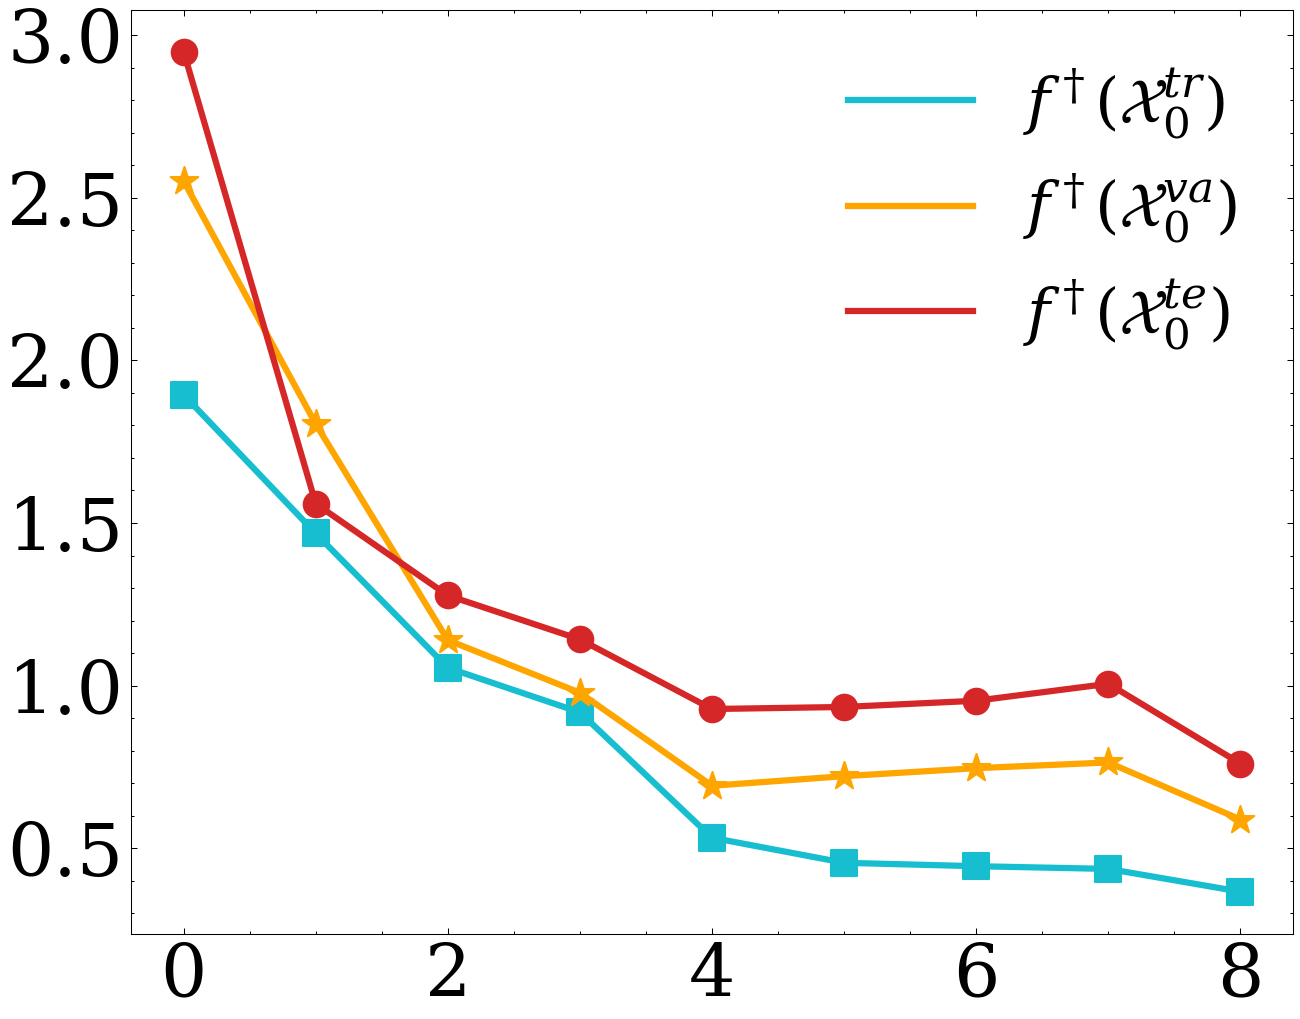

In [379]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_train)), s_train,color=color_trainig,s=size_points,marker=marker_trainig)
ax.plot(np.arange(0,len(s_train)), s_train,color=color_trainig,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_validation)), s_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_validation)), s_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_test)), s_test,color=color_testing,s=size_points,marker=marker_testing)
ax.plot(np.arange(0,len(s_test)), s_test,color=color_testing,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
# ax.set_xlabel(r'PC kept (p)',fontsize=40)
# ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

# plt.legend(fontsize=20,loc=(0.1,0.6))
plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.legend(fontsize=30)
plt.show()

In [385]:
s_validation

[2.5516161411136182,
 1.8043048618289734,
 1.139858297531309,
 0.9781101425277916,
 0.6921608512408751,
 0.721628674087164,
 0.7461971091112626,
 0.7636947951382375,
 0.5883013921529503]

In [386]:
s_test

[2.949107601379027,
 1.5593098438326465,
 1.2771693582640582,
 1.142224176933247,
 0.9280429795622425,
 0.9343672776394772,
 0.9535527334955991,
 1.0055986532207761,
 0.7602183783049341]